# Portefeuille Core-Satellite  Notebook Principal

Ce notebook orchestre l'intégralité du pipeline quantitatif Core/Satellite :

| Étape | Module | Rôle |
|-------|--------|------|
| 1 | `core_pipeline` | Sélection des 3 ETF Core (Equity / Rates / Credit) sur 2019-2020 |
| 2 | `efficient_frontier_core` | Comparaison de 5 stratégies d'allocation Core (Markowitz) |
| 3 | `satellite_pipeline` | Filtrage 4 niveaux, 3 blocs, 9 meilleurs fonds |
| 4 | `fond_construction` | Calibration 2019-2020  Backtest 2021-2025, bêta contrôlé |
| 5 | `plots_report` | 25 graphiques (Core / Satellite / Comparaison / Total) |

**Fenêtres de temps :**
- Calibration (IS) : 01/01/2019  31/12/2020
- Backtest (OOS) : 01/01/2021  31/12/2025

**Architecture :** tout est en rendements journaliers (log), pas de conversion mensuelle.

In [10]:
import os, sys
from pathlib import Path

# Se placer à la racine du projet
project_root = Path('/workspaces/Core_Satellite_Quant')
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print(f'Racine du projet : {Path.cwd()}')

Racine du projet : /workspaces/Core_Satellite_Quant


In [11]:
# Parametre unique de strategie Core (utilise partout dans le notebook)
# Options: 'max_sharpe_rolling', 'max_sharpe_is', 'min_variance_is', 'risk_parity_is', 'equal_weight'
core_choice = 'max_sharpe_rolling'
print(f"Core choisi (global): {core_choice}")

Core choisi (global): max_sharpe_rolling


---
## Étape 1  Sélection des ETF Core

**Objectif :** identifier, parmi l'univers Bloomberg Cross-Asset, le meilleur ETF  
dans chacun des 3 thèmes (Equity / Rates / Credit) sur la fenêtre de calibration 2019-2020.

**Critères :** Sharpe IS, Max Drawdown IS, liquidité (volume), frais (TER).  
Les prix de clôture ajustés sont utilisés ; les rendements sont calculés en log journalier.

In [12]:
from src.core_pipeline import main as core_main
core_main()

[1/7] Lecture Equity (nouveau fichier)...


  -> 59 ETFs uniques | 2010-01-04 à 2026-03-05
[2/7] Filtrage Equity : début ≤ 2019-01-01 | daily (gap ≤ 2.0) | expense ≤ 0.88 %
  -> 59 total | excl. date 22 | excl. fréq 0 | excl. frais 1
  -> ✓ 37 ETFs Equity retenus
[3/7] Lecture Rates / Credit (ancien fichier)...
  -> 13 ETFs Rates/Credit | 2010-01-04 à 2025-12-31
     IEGA LN Equity             bucket = Rates EMU Govies (Core)
     CBE3 LN Equity             bucket = Rates EMU Govies (Bucket)
     CBE5 LN Equity             bucket = Rates EMU Govies (Bucket)
     IBGY LN Equity             bucket = Rates EMU Govies (Bucket)
     IBGM LN Equity             bucket = Rates EMU Govies (Bucket)
     IEGZ NA Equity             bucket = Rates EMU Govies (Bucket)
     IBGL NA Equity             bucket = Rates EMU Govies (Bucket)
     IBCI GR Equity             bucket = Rates EMU Govies (Linkers)
     IEAC LN Equity             bucket = Credit EMU IG (Core)
     IE15 LN Equity             bucket = Credit EMU IG (Bucket)
     IBCX LN Equit

In [13]:
core_df = pd.read_csv("outputs/Core_finaux.csv")
print("\u2705 3 ETF Core sélectionnés :")
display(core_df.style.hide(axis="index"))

✅ 3 ETF Core sélectionnés :


Ticker,Theme
DJSC LN Equity,Equity
CBE3 LN Equity,Rates
IEAC LN Equity,Credit


---
## Étape 2  Comparaison des stratégies d'allocation Core (Frontière Efficiente)

Cinq stratégies d'allocation sont comparées sur les 3 ETF Core sélectionnés :

| Stratégie | Description |
|-----------|-------------|
| **Max Sharpe (IS)** | Optimisation quadratique sur 2019-2020, poids fixés |
| **Min Variance (IS)** | Minimisation de la variance sur 2019-2020, poids fixés |
| **Equal Weight** | 1/3 par ETF, rééquilibré annuellement |
| **Risk Parity** | Pondération proportionnelle à 1/σ (volatilité inverse) |
| **Max Sharpe Rolling** | Fenêtre glissante 252j, rebalancement 63j (**stratégie retenue**) |

> Les stratégies sont calibrées sur 2019-2020 (IS) et évaluées sur 2021-2025 (OOS).

In [14]:
from src.efficient_frontier_core import main as frontier_main
strategies, comp_df = frontier_main()

  COMPARAISON DES STRATÉGIES CORE (Markowitz daily)
  IS   : 2019-01-01 → 2020-12-31
  OOS  : 2021-01-01 → 2025-12-31

[1] Chargement des log-rendements journaliers des 3 ETF...
  ETFs : ['DJSC LN Equity', 'CBE3 LN Equity', 'IEAC LN Equity']
  Période : 2010-09-16 → 2026-03-05
  IS  : 514 obs | OOS : 1283 obs

[2] Simulation de la frontière (IS)...

[3] Optimisation des 4 stratégies statiques sur IS...
  Max Sharpe              w=[39.3%, 5.0%, 55.7%]  IS Sharpe=0.75  OOS Sharpe=0.05
  Min Variance            w=[5.0%, 70.0%, 25.0%]  IS Sharpe=0.59  OOS Sharpe=0.07
  Equal Weight            w=[33.3%, 33.3%, 33.3%]  IS Sharpe=0.74  OOS Sharpe=0.15
  Risk Parity             w=[4.0%, 84.1%, 11.9%]  IS Sharpe=0.54  OOS Sharpe=0.28

[4] Backtest rolling Max Sharpe (252j lookback, 63j rebal)...
  Max Sharpe Rolling      (rolling)  IS Sharpe=0.99  OOS Sharpe=0.10

  TABLEAU COMPARATIF

Stratégie                    IS Ret   IS Vol   IS Sh  OOS Ret  OOS Vol  OOS Sh   OOS MDD
---------------------

In [15]:
cols_is  = ['IS_ret_ann','IS_vol_ann','IS_sharpe']
cols_oos = ['OOS_ret_ann','OOS_vol_ann','OOS_sharpe','OOS_mdd']
fmt_pct  = {c: '{:.1%}' for c in cols_is + cols_oos if 'sharpe' not in c}
fmt_num  = {c: '{:.2f}' for c in cols_is + cols_oos if 'sharpe' in c}

print('=== IS (Calibration 2019-2020) ===')
display(comp_df[cols_is].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['IS_ret_ann','IS_sharpe'], color='lightgreen')
        .highlight_min(subset=['IS_vol_ann'], color='lightblue'))

print('\n=== OOS (Backtest 2021-2025) ===')
display(comp_df[cols_oos].style.format({**fmt_pct, **fmt_num})
        .highlight_max(subset=['OOS_ret_ann','OOS_sharpe'], color='lightgreen')
        .highlight_min(subset=['OOS_vol_ann','OOS_mdd'], color='lightblue'))

=== IS (Calibration 2019-2020) ===


,IS_ret_ann,IS_vol_ann,IS_sharpe
strategie,,,
Max Sharpe,7.2%,9.5%,0.75
Min Variance,1.5%,2.6%,0.59
Equal Weight,5.6%,7.6%,0.74
Risk Parity,0.9%,1.7%,0.54
Max Sharpe Rolling,8.1%,8.2%,0.99



=== OOS (Backtest 2021-2025) ===


,OOS_ret_ann,OOS_vol_ann,OOS_sharpe,OOS_mdd
strategie,,,,
Max Sharpe,0.4%,7.3%,0.05,-20.4%
Min Variance,0.1%,2.2%,0.07,-9.0%
Equal Weight,0.9%,5.9%,0.15,-16.4%
Risk Parity,0.5%,1.8%,0.28,-7.1%
Max Sharpe Rolling,0.9%,8.8%,0.10,-21.5%


Frontière efficiente IS (2019-2020) + 5 stratégies


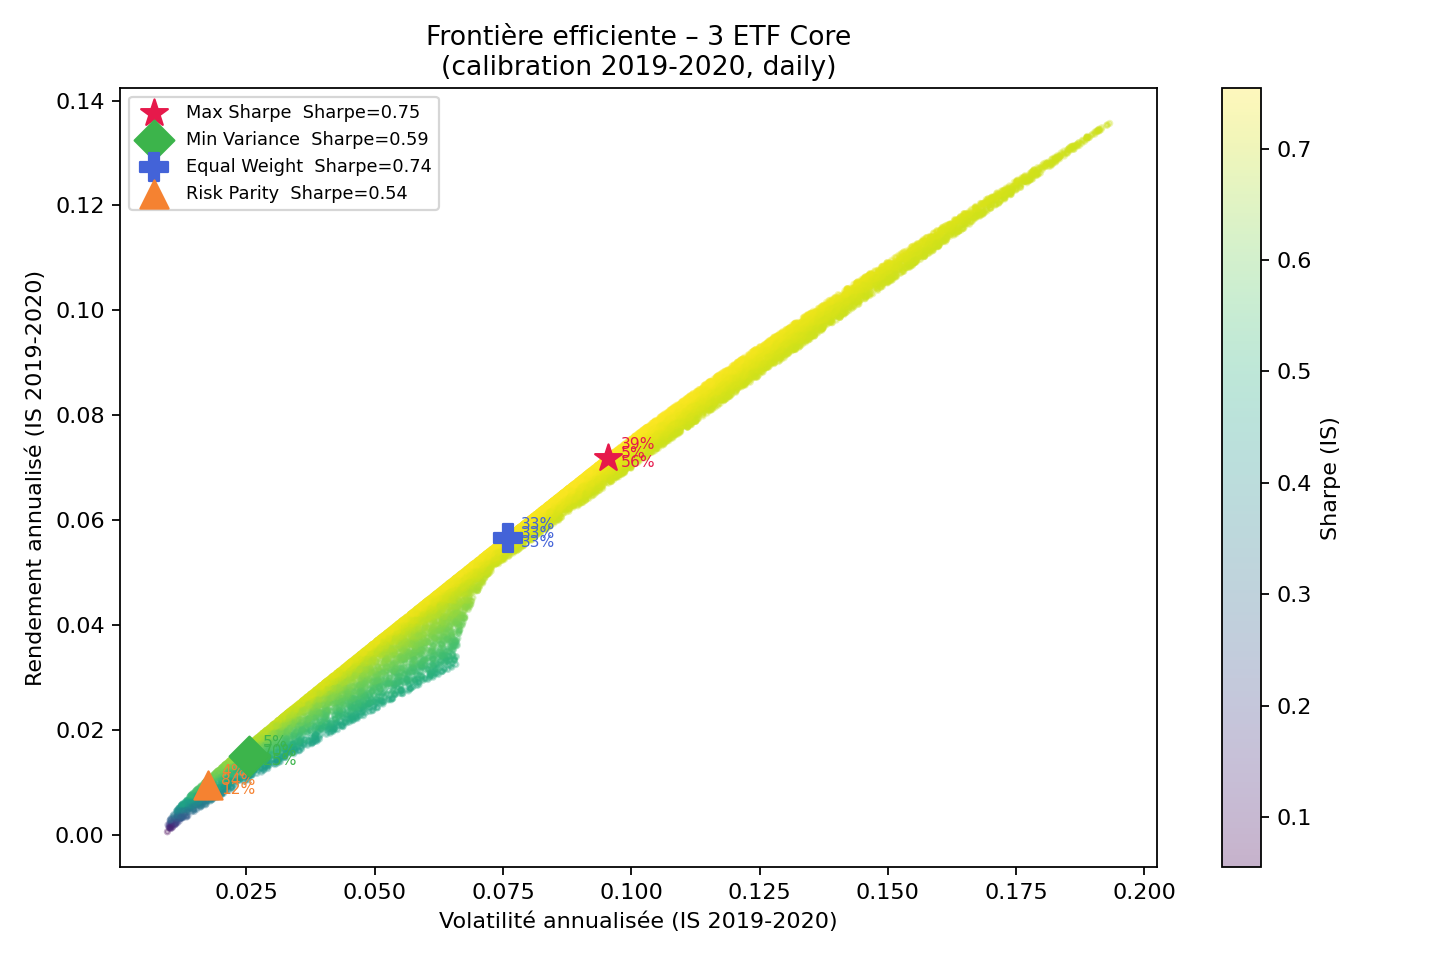

In [16]:
print('Frontière efficiente IS (2019-2020) + 5 stratégies')
display(Image('outputs/figures/06_efficient_frontier_core.png'))

Performance cumulée OOS (2021-2025) des 5 stratégies


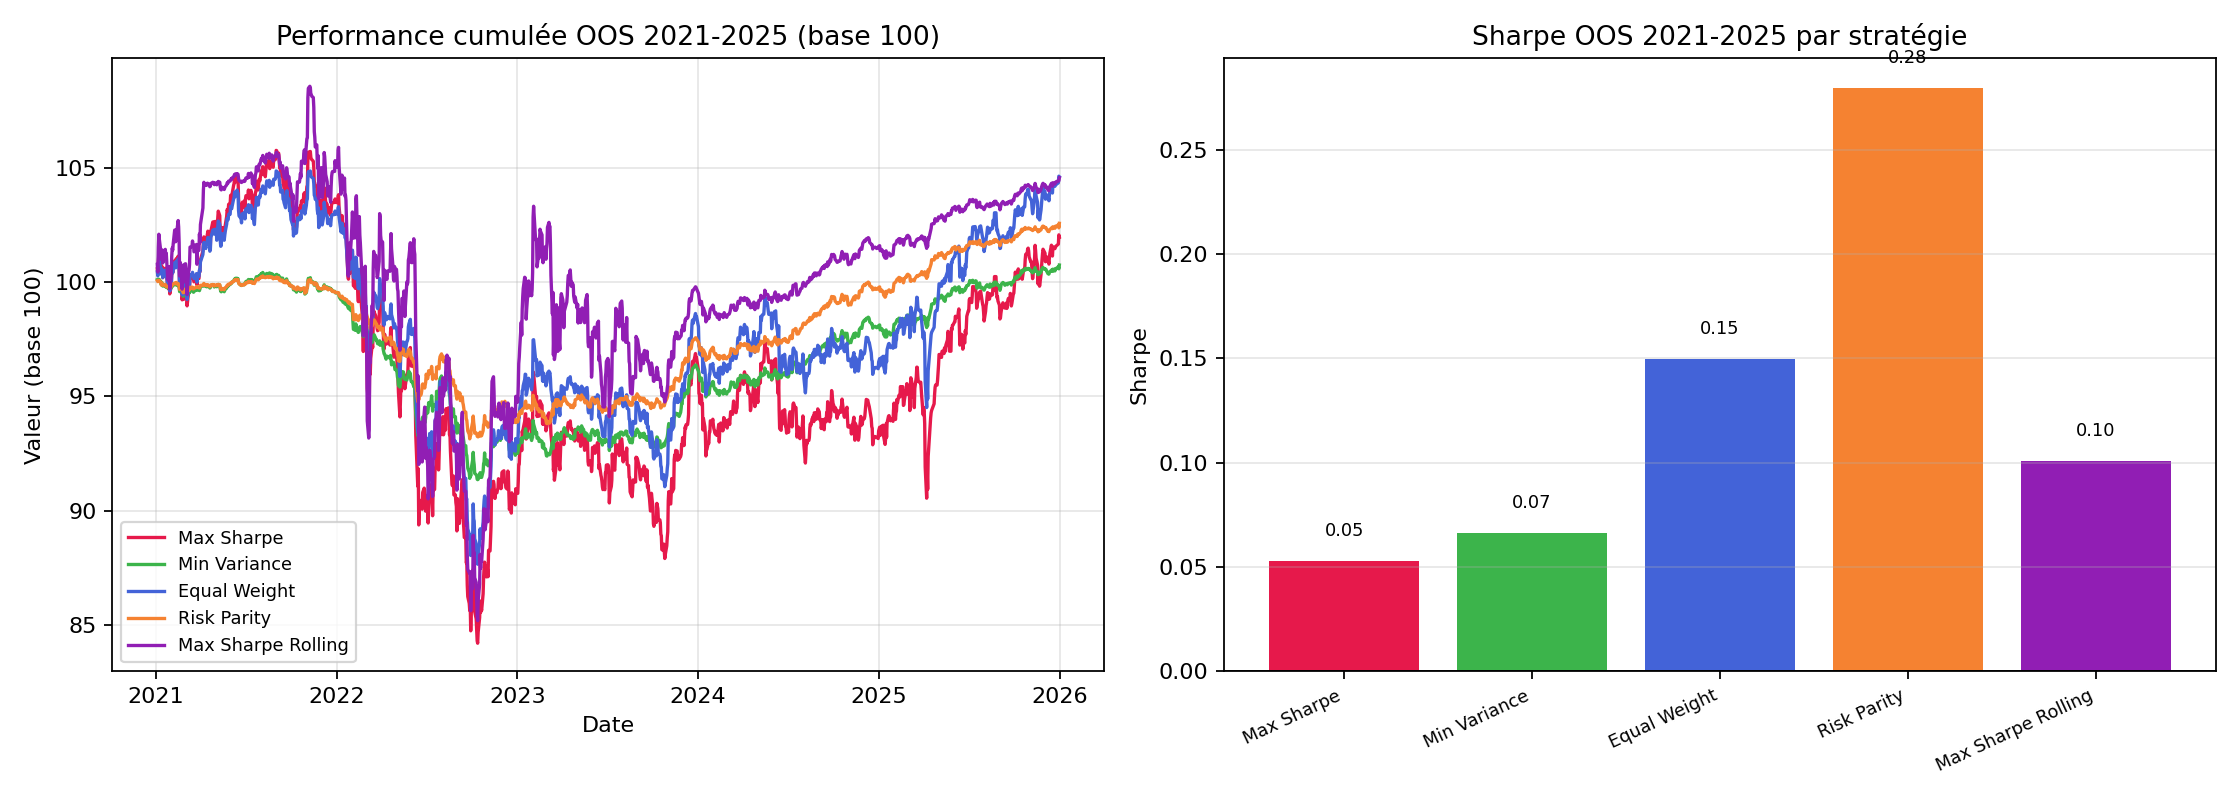

In [17]:
print('Performance cumulée OOS (2021-2025) des 5 stratégies')
display(Image('outputs/figures/07_core_strategies_oos_perf.png'))

---
## Étape 3  Sélection des fonds Satellite

Filtrage en **4 niveaux** sur ~890 fonds alternatifs, organisés en 3 blocs :

- **Bloc 1 (Décorrélation)** : Long Volatilité, Tail Risk, Optionnel  convexité du portefeuille
- **Bloc 2 (Alpha contrôlé)** : Market Neutral, L/S Equity, CTA  alpha systématique, bêta  0.25
- **Bloc 3 (Macro)** : Commodities, ILS/Cat Bonds, ARP  moteurs orthogonaux au cycle

Les niveaux de filtrage :
1. **Structurel** : AUM  100M€, métriques complètes
2. **Frais & Vol** : plafonds adaptés par bloc
3. **Qualité quant** : Sharpe, Alpha, MDD
4. **Distribution** : Skewness, Kurtosis, diversification

In [18]:
from src.satellite_pipeline import main as sat_main, SatelliteConfig

# Parametres pilotables depuis le notebook
sat_stale_max_ratio = 0.1  # 10% de données manquantes max pour un satellite (ratio de données manquantes sur données totales)
sat_vol_min_bloc23 = 0.06  # 10% annualise pour les blocs 2 et 3

cfg = SatelliteConfig(stale_max_ratio=sat_stale_max_ratio)
cfg.blocs['Bloc2'].vol_min_default = sat_vol_min_bloc23
cfg.blocs['Bloc3'].vol_min_default = sat_vol_min_bloc23

print(f"Stale max ratio: {sat_stale_max_ratio:.0%}")
print(f"Vol min Bloc2/Bloc3: {sat_vol_min_bloc23:.0%}")

sat_main(cfg)

Stale max ratio: 10%
Vol min Bloc2/Bloc3: 6%
  PIPELINE SATELLITE v2 – Filtrage & Sélection
  Fenêtre calib : 2019-01-01 → 2020-12-31

[1] Chargement des rendements Core...
    3717 obs. daily | 2011-09-07 → 2026-03-04
    Benchmark filtre beta : Core équipondéré (3 ETF sélectionnés via CSV)
    3969 obs. daily | 2010-09-17 → 2026-03-05

  Bloc 1 – Décorrélation / Convexité


  [données] 74 fonds avec prix ET info
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équipondéré...
  [Niv.Beta] |beta| <= 25% sur >= 70% jours     6 / 74
             6 fonds avec données suffisantes
  [Niv.0] AUM/Date/Devise/Excl.    2 / 74
  [Niv.1] Frais/Vol[0%,20%]/Stale<= 10%   2 / 2
  [Niv.2] Sharpe/Alpha/Drawdown    2 / 2
  [Niv.3] Skew/Kurt/Conc.          1 / 2

  [sélection] Bloc1 – 1 fonds retenus :
    #1  BFIST5I LX Equity             strat=Dérivés                       score=+0.000  β=+0.081  Sharpe=0.634

  [beta rolling 252j]...

  Bloc 2 – Alpha avec bêta contrôlé
  [données] 301 fonds avec prix ET info
  [métriques] Calcul sur calib 2019-01-01 → 2020-12-31...
  [beta init] Rolling 63j vs Core équipondéré...
  [Niv.Beta] |beta| <= 25% sur >= 70% jours    77 / 301
             77 fonds avec données suffisantes
  [Niv.0] AUM/Date/Devise/Excl.   58 / 301
  [Niv.1] Frais/Vol[6%,10%]/Stale<= 10%   2 / 58
  [Niv.2] Sharpe/Alpha/D

In [19]:
sat_sel = pd.read_csv('outputs/satellite_selected.csv').set_index('ticker')
cols_show = [c for c in ['bloc','strategie','sharpe','alpha','mdd','aum','expense_pct'] if c in sat_sel.columns]
fmt = {c: ('{:.2f}' if c in ['sharpe','alpha'] else ('{:.1%}' if c in ['mdd','expense_pct'] else '{}'))
       for c in cols_show}
print(f'{len(sat_sel)} fonds satellite sélectionnés :')
display(sat_sel[cols_show].sort_values('bloc').style.format(fmt))

5 fonds satellite sélectionnés :


,bloc,strategie,expense_pct
ticker,,,
BFIST5I LX Equity,Bloc1,Dérivés,148.0%
SCHTSIC LX Equity,Bloc2,Multi-stratégie,182.0%
HANGOLD GR Equity,Bloc3,Métaux précieux,91.0%
ALBKOCA SW Equity,Bloc3,Protégé contre l'inflation,34.0%
RLINLRA LN Equity,Bloc3,Protégé contre l'inflation,8.0%


---
## Étape 4 — Construction et backtest du fonds Core-Satellite

**Principes :**
- **Poche Core (70-75 %)** : stratégie Max-Sharpe Rolling sur les 3 ETF
- **Poche Satellite (25-30 %)** : allocation **equal-weight (1/n)** sur les fonds retenus
- Calibration de w_core / w_sat sur 2019-2020 pour atteindre la vol cible [4%, 15%]
- Rebalancement trimestriel (tous les 63 jours ouvrés)
- Seuls les fonds avec données en période de calibration **et** de backtest sont retenus

**Backtest out-of-sample** : 01/01/2021 → 31/12/2025

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
from src.fond_construction import main as fond_main

project_root = Path('/workspaces/Core_Satellite_Quant')
core_daily_out = project_root / 'outputs' / 'core_returns_daily_oos.csv'
core3_path = project_root / 'outputs' / 'core3_etf_daily_log_returns.csv'

if 'core_choice' not in globals():
    raise ValueError("La variable globale 'core_choice' n'est pas definie. Execute la cellule de configuration au debut.")

valid_choices = {
    'max_sharpe_rolling', 'max_sharpe_is', 'min_variance_is', 'risk_parity_is', 'equal_weight'
}
if core_choice not in valid_choices:
    raise ValueError(f"core_choice invalide: {core_choice}")

# Parametres coherents avec le pipeline Core
calib_start, calib_end = '2019-01-01', '2020-12-31'
oos_start, oos_end = '2021-01-01', '2025-12-31'
lookback, rebal_freq = 252, 63
w_min, w_max = 0.05, 0.50

# Chargement log-rendements des 3 ETF Core
log_df = pd.read_csv(core3_path, index_col=0, parse_dates=True).sort_index()
if log_df.shape[1] != 3:
    raise ValueError(f"core3_etf_daily_log_returns.csv doit contenir 3 colonnes, trouve {log_df.shape[1]}")


def opt_max_sharpe_grid(mu, cov, w_min=0.05, w_max=0.50, step=0.005):
    best_w = np.ones(3) / 3
    best_sr = -np.inf
    grid = np.arange(w_min, w_max + 1e-12, step)
    for w1 in grid:
        for w2 in grid:
            w3 = 1.0 - w1 - w2
            if w3 < w_min or w3 > w_max:
                continue
            w = np.array([w1, w2, w3], dtype=float)
            vol = np.sqrt(w @ cov @ w)
            if vol <= 1e-12:
                continue
            sr = (w @ mu) / vol
            if sr > best_sr:
                best_sr = sr
                best_w = w
    return best_w / best_w.sum()


def opt_min_var_grid(cov, w_min=0.05, w_max=0.50, step=0.005):
    best_w = np.ones(3) / 3
    best_var = np.inf
    grid = np.arange(w_min, w_max + 1e-12, step)
    for w1 in grid:
        for w2 in grid:
            w3 = 1.0 - w1 - w2
            if w3 < w_min or w3 > w_max:
                continue
            w = np.array([w1, w2, w3], dtype=float)
            var = float(w @ cov @ w)
            if var < best_var:
                best_var = var
                best_w = w
    return best_w / best_w.sum()


def risk_parity(cov):
    vols = np.sqrt(np.diag(cov))
    inv_vol = 1.0 / np.maximum(vols, 1e-12)
    return inv_vol / inv_vol.sum()


# Conversion en rendements simples journaliers
simple_df = np.exp(log_df) - 1.0

if core_choice == 'max_sharpe_rolling':
    dates = log_df.index
    rets = []
    ret_dates = []
    for start in range(lookback, len(dates) - rebal_freq, rebal_freq):
        window = log_df.iloc[start - lookback:start]
        block = simple_df.iloc[start:start + rebal_freq]

        mu = window.mean().values * 252
        cov = window.cov().values * 252
        w = opt_max_sharpe_grid(mu, cov, w_min=w_min, w_max=w_max)

        r_block = block.values @ w
        rets.extend(r_block.tolist())
        ret_dates.extend(block.index.tolist())

    core_simple = pd.Series(rets, index=pd.DatetimeIndex(ret_dates), name='core_simple').sort_index()
    # IMPORTANT: conserver calib + OOS pour fond_main (2019-2025)
    core_simple = core_simple.loc[calib_start:oos_end]

else:
    is_log = log_df.loc[calib_start:calib_end].dropna()
    span_simple = simple_df.loc[calib_start:oos_end].dropna()

    mu_is = is_log.mean().values * 252
    cov_is = is_log.cov().values * 252

    if core_choice == 'max_sharpe_is':
        w = opt_max_sharpe_grid(mu_is, cov_is, w_min=w_min, w_max=w_max)
    elif core_choice == 'min_variance_is':
        w = opt_min_var_grid(cov_is, w_min=w_min, w_max=w_max)
    elif core_choice == 'risk_parity_is':
        w = risk_parity(cov_is)
    elif core_choice == 'equal_weight':
        w = np.ones(3) / 3

    # IMPORTANT: serie daily sur 2019-2025, pas seulement OOS
    core_simple = pd.Series(span_simple.values @ w, index=span_simple.index, name='core_simple')

# Ecriture dans le format attendu par fond_construction
core_log_out = np.log1p(core_simple).rename('core_log_return_oos')
core_log_out.to_frame().to_csv(core_daily_out)

# Controle rapide de couverture temporelle
a = core_log_out.loc[calib_start:calib_end]
b = core_log_out.loc[oos_start:oos_end]
print(f"Core injecte pour le portefeuille final: {core_choice}")
print(f"Couverture calib (2019-2020): {len(a)} jours")
print(f"Couverture OOS (2021-2025): {len(b)} jours")
print(f"Fichier ecrit: {core_daily_out}")

# Construction portefeuille final avec le Core choisi
fond_main()

Core injecte pour le portefeuille final: max_sharpe_rolling
Couverture calib (2019-2020): 514 jours
Couverture OOS (2021-2025): 1283 jours
Fichier ecrit: /workspaces/Core_Satellite_Quant/outputs/core_returns_daily_oos.csv
  CONSTRUCTION DU FONDS CORE-SATELLITE
  Calibration : 2019-01-01 → 2020-12-31
  Backtest    : 2021-01-01 → 2025-12-31

[1] Chargement des données...
    Core  : 1797 obs. | 2019-01-02 → 2025-12-31
    Satellite : 5 fonds | 2010-01-01 → 2025-12-31
    Couverture par période :
      BFIST5I LX Equity               calib=502 obs  oos=1250 obs  ✓
      SCHTSIC LX Equity               calib=500 obs  oos=1245 obs  ✓
      HANGOLD GR Equity               calib=503 obs  oos=1261 obs  ✓
      ALBKOCA SW Equity               calib=503 obs  oos= 936 obs  ✓
      RLINLRA LN Equity               calib=506 obs  oos=1260 obs  ✓

  Blocs (3) : {'Bloc1': 1, 'Bloc2': 1, 'Bloc3': 3}

[2] Allocation equal-weight des poids satellite...
  Fonds retenus : 5 / 5
  Poids par fonds (equal-wei

In [21]:
metrics = pd.read_csv('outputs/fond_metrics.csv', index_col=0)
print('Métriques du fonds Core-Satellite (OOS 2021-2025) :')
display(metrics.style.format('{:.4f}'))

Métriques du fonds Core-Satellite (OOS 2021-2025) :


,valeur
vol_portfolio_ann,0.0522
ret_ann_portfolio,0.0136
sharpe_portfolio,0.2606
max_drawdown,-0.1649
alpha_portfolio_ann,0.0072
beta_portfolio,0.7580
vol_core_ann,0.0664
ret_ann_core,0.0079
sharpe_core,0.1197
vol_satellite_ann,0.0554


In [22]:
w_df = pd.read_csv('outputs/fond_weights.csv', index_col=0)
print('Poids de la poche satellite (theta = poids dans la poche, poids_absolu = w_sat  theta) :')
display(w_df.style.format('{:.4f}').bar(subset=['theta_satellite'], color='#3cb44b').bar(subset=['w_sat'], color='#4363d8'))

Poids de la poche satellite (theta = poids dans la poche, poids_absolu = w_sat  theta) :


,theta_satellite,absolute_weight,w_core,w_sat,portfolio_scale
BFIST5I LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000
SCHTSIC LX Equity,0.2000,0.0500,0.7500,0.2500,1.0000
HANGOLD GR Equity,0.2000,0.0500,0.7500,0.2500,1.0000
ALBKOCA SW Equity,0.2000,0.0500,0.7500,0.2500,1.0000
RLINLRA LN Equity,0.2000,0.0500,0.7500,0.2500,1.0000



Poids satellites aux dates de rebalancement trimestriel :


,BFIST5I LX Equity,SCHTSIC LX Equity,HANGOLD GR Equity,ALBKOCA SW Equity,RLINLRA LN Equity
2021-04-01 00:00:00,5.07%,4.83%,4.61%,4.97%,4.68%
2021-07-01 00:00:00,5.11%,5.16%,5.03%,4.92%,5.09%
2021-09-28 00:00:00,4.95%,4.92%,4.79%,4.95%,5.32%
2021-12-24 00:00:00,5.13%,5.26%,5.01%,4.93%,5.16%
2022-03-23 00:00:00,4.98%,5.24%,5.49%,4.88%,4.68%
2022-06-22 00:00:00,5.08%,5.32%,5.00%,4.94%,4.38%
2022-09-19 00:00:00,5.13%,5.05%,4.72%,5.08%,4.73%
2022-12-15 00:00:00,4.94%,4.93%,5.32%,5.04%,4.52%
2023-03-15 00:00:00,4.75%,5.03%,4.89%,4.82%,4.84%
2023-06-15 00:00:00,5.13%,4.96%,5.11%,4.90%,4.53%


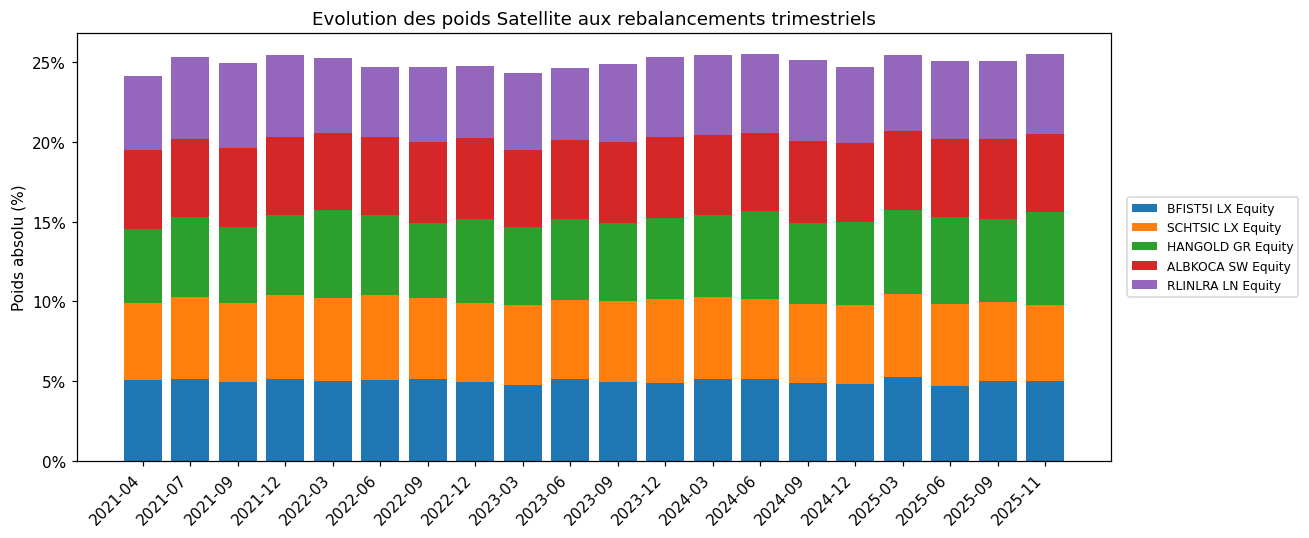

In [23]:
# Evolution des poids satellite pendant le backtest (drift + rebal trimestriel)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inputs du backtest deja exportes par fond_construction.py
w_init = pd.read_csv('outputs/fond_weights.csv', index_col=0)
metrics = pd.read_csv('outputs/fond_metrics.csv', index_col=0)
core_ret = pd.read_csv('outputs/fond_returns_daily.csv', index_col=0, parse_dates=True)['core_ret']
sat_indiv = pd.read_csv('outputs/satellite_individual_returns.csv', index_col=0, parse_dates=True)

w_core_target = float(metrics.loc['w_core', metrics.columns[0]])
w_sat_target = float(metrics.loc['w_sat', metrics.columns[0]])
rebal_freq = 63  # trimestriel (jours ouvres)

# Theta (poids dans la poche satellite), puis poids absolus initiaux
theta = w_init['theta_satellite'].dropna().reindex(sat_indiv.columns).fillna(0.0)
w_s = theta.values * w_sat_target
w_c = w_core_target

dates = core_ret.index.intersection(sat_indiv.index)
core = core_ret.loc[dates]
sat = sat_indiv.loc[dates].fillna(0.0)

gross_target = w_core_target + w_sat_target

weights_daily = []
rebal_dates = []
last_rebal = 0

for i, dt in enumerate(dates):
    # Stocke les poids AVANT rendement du jour (opening weights)
    row = {t: w for t, w in zip(sat.columns, w_s)}
    row['w_core'] = w_c
    row['w_sat_total'] = w_s.sum()
    row['Date'] = dt
    weights_daily.append(row)

    # Rendements du jour
    rc = float(core.iloc[i])
    rs = sat.iloc[i].values

    # Drift overnight
    w_c_new = w_c * (1.0 + rc)
    w_s_new = w_s * (1.0 + rs)
    tot = w_c_new + w_s_new.sum()
    if tot > 1e-12:
        w_c = gross_target * (w_c_new / tot)
        w_s = gross_target * (w_s_new / tot)

    # Rebalancement tous les 63 jours
    if (i - last_rebal) >= rebal_freq and i < len(dates) - 1:
        rebal_dates.append(dt)
        w_c = w_core_target
        w_s = theta.values * w_sat_target
        last_rebal = i

weights_daily = pd.DataFrame(weights_daily).set_index('Date').sort_index()


# Tableau aux dates de rebalancement
rebal_df = weights_daily.loc[weights_daily.index.intersection(pd.DatetimeIndex(rebal_dates))]
print('\nPoids satellites aux dates de rebalancement trimestriel :')
display(rebal_df[sat.columns].style.format('{:.2%}'))

# Bar plot empile des poids satellites au moment du rebalancement
if not rebal_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(rebal_df.index))
    bottom = np.zeros(len(rebal_df.index))

    for col in sat.columns:
        vals = rebal_df[col].values
        ax.bar(x, vals, bottom=bottom, label=col)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime('%Y-%m') for d in rebal_df.index], rotation=45, ha='right')
    ax.set_ylabel('Poids absolu (%)')
    ax.set_title('Evolution des poids Satellite aux rebalancements trimestriels')
    ax.yaxis.set_major_formatter(lambda v, p: f'{v:.0%}')
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Aucune date de rebalancement detectee dans la periode.')

Core choisi (global) pour visualisation: max_sharpe_rolling

Poids Core aux dates trimestrielles affichees :


,DJSC LN Equity [Equity],CBE3 LN Equity [Rates],IEAC LN Equity [Credit]
Date,,,
2021-01-08 00:00:00,50.00%,45.00%,5.00%
2021-04-09 00:00:00,9.50%,50.00%,40.50%
2021-07-07 00:00:00,18.50%,32.00%,49.50%
2021-10-04 00:00:00,50.00%,5.50%,44.50%
2021-12-30 00:00:00,50.00%,45.00%,5.00%
2022-03-29 00:00:00,50.00%,45.00%,5.00%
2022-06-28 00:00:00,50.00%,45.00%,5.00%
2022-09-23 00:00:00,50.00%,45.00%,5.00%
2022-12-21 00:00:00,50.00%,45.00%,5.00%


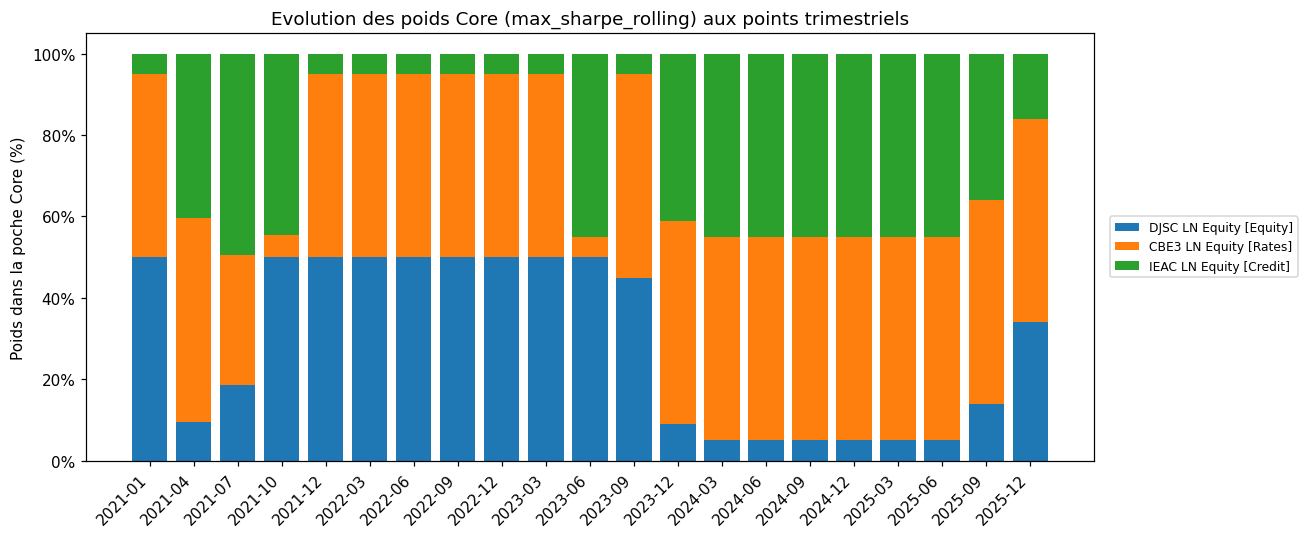

In [24]:
# Evolution des poids Core pendant le backtest (adapte au Core choisi)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1) Choix du Core a visualiser
# ==============================
# La cellule lit le parametre global core_choice.
# Si absent, fallback sur max_sharpe_rolling.
core_choice = globals().get('core_choice', 'max_sharpe_rolling')

# Options:
# - 'max_sharpe_rolling'  (celui utilise dans le portefeuille final actuel par defaut)
# - 'max_sharpe_is'       (poids statiques calibres sur 2019-2020)
# - 'min_variance_is'     (poids statiques calibres sur 2019-2020)
# - 'risk_parity_is'      (poids statiques calibres sur 2019-2020)
# - 'equal_weight'        (1/3, 1/3, 1/3)

# ==============================
# 2) Inputs et parametres
# ==============================
core_log = pd.read_csv('outputs/core3_etf_daily_log_returns.csv', index_col=0, parse_dates=True).sort_index()
core_finaux = pd.read_csv('outputs/Core_finaux.csv')

calib_start, calib_end = '2019-01-01', '2020-12-31'
oos_start, oos_end = '2021-01-01', '2025-12-31'
lookback = 252
rebal_freq = 63
w_min, w_max = 0.05, 0.50

if core_log.shape[1] != 3:
    raise ValueError(f"Cette cellule est prevue pour 3 ETF Core. Trouve: {core_log.shape[1]} colonnes")


def opt_max_sharpe_grid(mu, cov, w_min=0.05, w_max=0.50, step=0.005):
    best_w = np.ones(3) / 3
    best_sr = -np.inf
    grid = np.arange(w_min, w_max + 1e-12, step)

    for w1 in grid:
        for w2 in grid:
            w3 = 1.0 - w1 - w2
            if w3 < w_min or w3 > w_max:
                continue
            w = np.array([w1, w2, w3], dtype=float)
            vol = np.sqrt(w @ cov @ w)
            if vol <= 1e-12:
                continue
            sr = (w @ mu) / vol
            if sr > best_sr:
                best_sr = sr
                best_w = w

    return best_w / best_w.sum()


def opt_min_var_grid(cov, w_min=0.05, w_max=0.50, step=0.005):
    best_w = np.ones(3) / 3
    best_var = np.inf
    grid = np.arange(w_min, w_max + 1e-12, step)

    for w1 in grid:
        for w2 in grid:
            w3 = 1.0 - w1 - w2
            if w3 < w_min or w3 > w_max:
                continue
            w = np.array([w1, w2, w3], dtype=float)
            var = float(w @ cov @ w)
            if var < best_var:
                best_var = var
                best_w = w

    return best_w / best_w.sum()


def risk_parity(cov):
    vols = np.sqrt(np.diag(cov))
    inv_vol = 1.0 / np.maximum(vols, 1e-12)
    return inv_vol / inv_vol.sum()


# ==============================
# 3) Construction trajectoire poids
# ==============================
weights_rows = []
rebal_rows = []
dates = core_log.index

if core_choice == 'max_sharpe_rolling':
    # Meme logique que le pipeline final: recalibration tous les 63j
    for start in range(lookback, len(dates) - rebal_freq, rebal_freq):
        window = core_log.iloc[start - lookback:start]
        oos = core_log.iloc[start:start + rebal_freq]

        mu = window.mean().values * 252
        cov = window.cov().values * 252
        w = opt_max_sharpe_grid(mu, cov, w_min=w_min, w_max=w_max)

        for dt in oos.index:
            weights_rows.append({'Date': dt, **{c: wi for c, wi in zip(core_log.columns, w)}})

        rebal_rows.append({'Date': oos.index[0], **{c: wi for c, wi in zip(core_log.columns, w)}})

else:
    # Strategies statiques calibrees sur IS 2019-2020
    is_df = core_log.loc[calib_start:calib_end].dropna()
    mu_is = is_df.mean().values * 252
    cov_is = is_df.cov().values * 252

    if core_choice == 'max_sharpe_is':
        w = opt_max_sharpe_grid(mu_is, cov_is, w_min=w_min, w_max=w_max)
    elif core_choice == 'min_variance_is':
        w = opt_min_var_grid(cov_is, w_min=w_min, w_max=w_max)
    elif core_choice == 'risk_parity_is':
        w = risk_parity(cov_is)
    elif core_choice == 'equal_weight':
        w = np.ones(3) / 3
    else:
        raise ValueError(f"core_choice inconnu: {core_choice}")

    oos_idx = core_log.loc[oos_start:oos_end].index
    for dt in oos_idx:
        weights_rows.append({'Date': dt, **{c: wi for c, wi in zip(core_log.columns, w)}})

    # Reperes trimestriels pour le graphique (meme cadence visuelle)
    for i in range(0, len(oos_idx), rebal_freq):
        dt = oos_idx[i]
        rebal_rows.append({'Date': dt, **{c: wi for c, wi in zip(core_log.columns, w)}})


core_weights_daily = pd.DataFrame(weights_rows).set_index('Date').sort_index()
core_weights_daily = core_weights_daily.loc[oos_start:oos_end]

core_rebal = pd.DataFrame(rebal_rows).set_index('Date').sort_index()
core_rebal = core_rebal.loc[oos_start:oos_end]

# Labels ETF + theme
if {'Ticker', 'Theme'}.issubset(core_finaux.columns):
    label_map = {
        row['Ticker']: f"{row['Ticker']} [{row['Theme']}]"
        for _, row in core_finaux.iterrows()
        if row['Ticker'] in core_weights_daily.columns
    }
else:
    label_map = {}

core_weights_daily = core_weights_daily.rename(columns=label_map)
core_rebal = core_rebal.rename(columns=label_map)

print(f"Core choisi (global) pour visualisation: {core_choice}")

# Tableau aux dates de rebalancement
print('\nPoids Core aux dates trimestrielles affichees :')
display(core_rebal.style.format('{:.2%}'))

# Bar plot empile
if not core_rebal.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(core_rebal.index))
    bottom = np.zeros(len(core_rebal.index))

    for col in core_rebal.columns:
        vals = core_rebal[col].values
        ax.bar(x, vals, bottom=bottom, label=col)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime('%Y-%m') for d in core_rebal.index], rotation=45, ha='right')
    ax.set_ylabel('Poids dans la poche Core (%)')
    ax.set_title(f"Evolution des poids Core ({core_choice}) aux points trimestriels")
    ax.yaxis.set_major_formatter(lambda v, p: f'{v:.0%}')
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Aucune date disponible pour le graphique.')

In [25]:
ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
ann.index = ann.index.astype(int)
print('Performance annuelle :')
display(ann.style.format('{:.2%}')
        .map(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))

Performance annuelle :


,portfolio,core,satellite
2021,3.22%,3.57%,2.07%
2022,-8.69%,-8.15%,-10.29%
2023,4.90%,4.62%,5.72%
2024,2.29%,1.37%,5.05%
2025,5.91%,3.20%,14.40%


---
## Étape 5  Visualisations complètes

Génération de **24 graphiques** organisés en 4 sections :

| Section | Figures | Contenu |
|---------|---------|--------|
| **A**  Poche Core | A01A07 | ETF individuels, portefeuille, drawdown, vol rolling, Sharpe, annuel, frais |
| **B**  Poche Satellite | B01B07 | Fonds individuels, poche agrégée, poids, alpha/beta rolling, annuel, frais |
| **C**  Core vs Satellite | C01C04 | Comparaison cumulée, excès, performance annuelle groupée |
| **D**  Portefeuille total | D01D06 | Performance, drawdown, annuel, vol vs cible, beta satellite, distribution |

  GÉNÉRATION DES GRAPHIQUES – RAPPORT CORE-SATELLITE

[1] Chargement des données...
    Backtest : 2021-01-04 → 2025-12-31 (1283 obs)

[2] Section A – Poche Core (7 figures)...


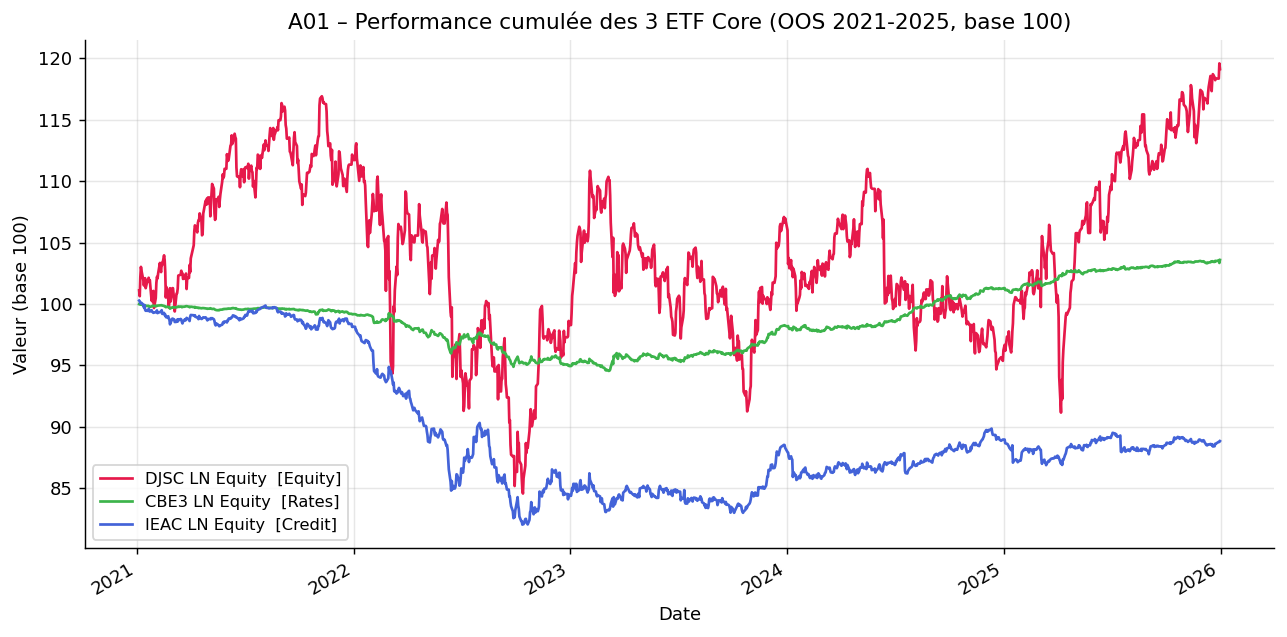

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A01_core_etf_cum.png


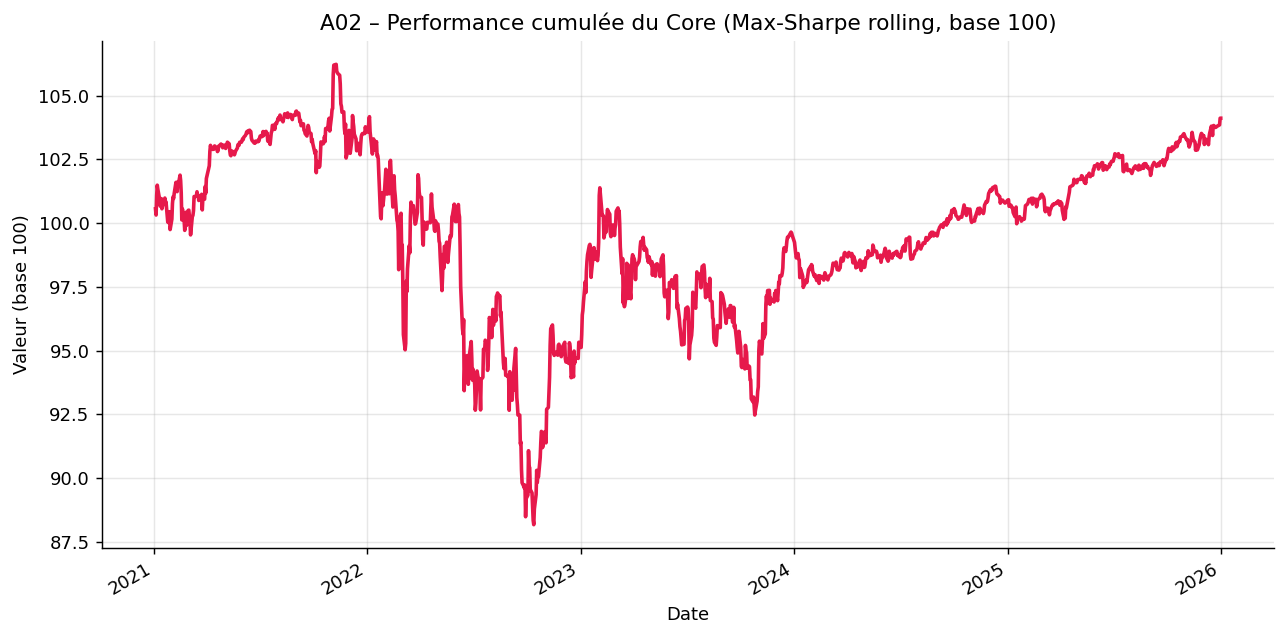

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A02_core_portfolio_cum.png


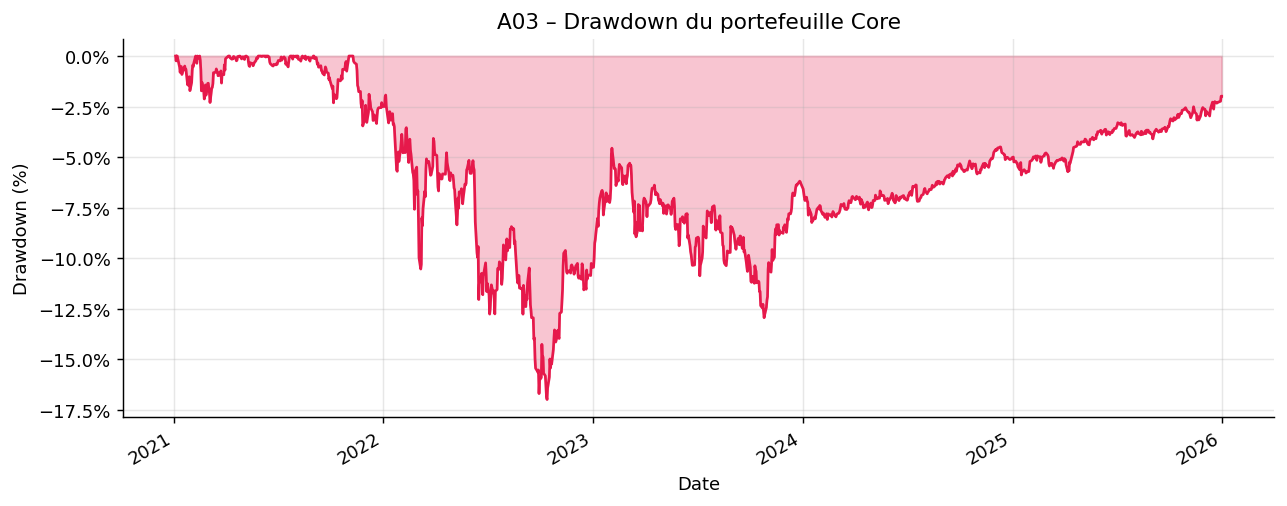

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A03_core_drawdown.png


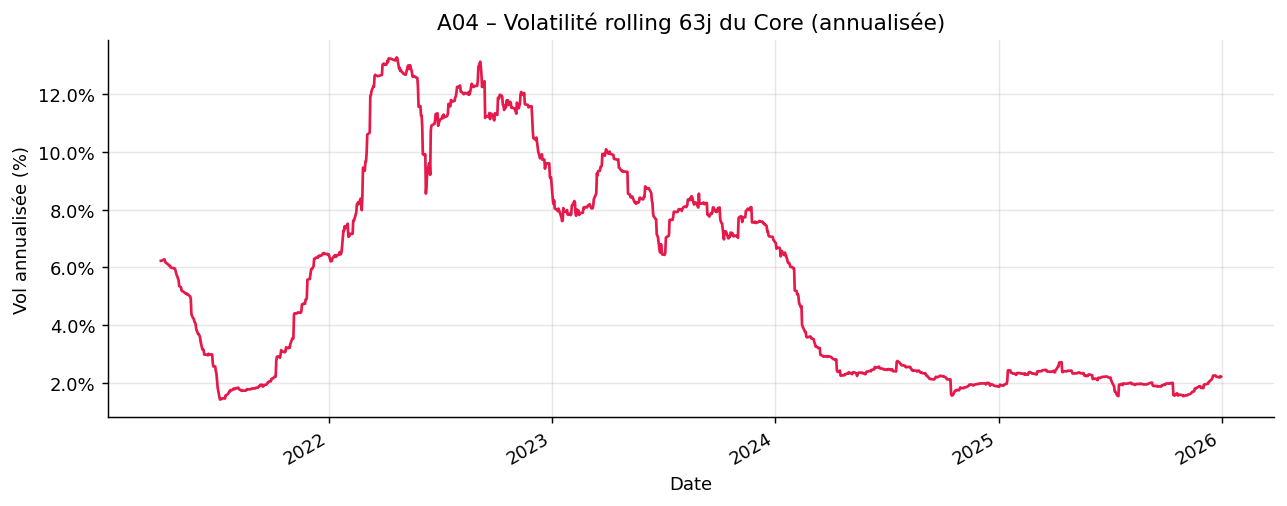

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A04_core_rolling_vol.png


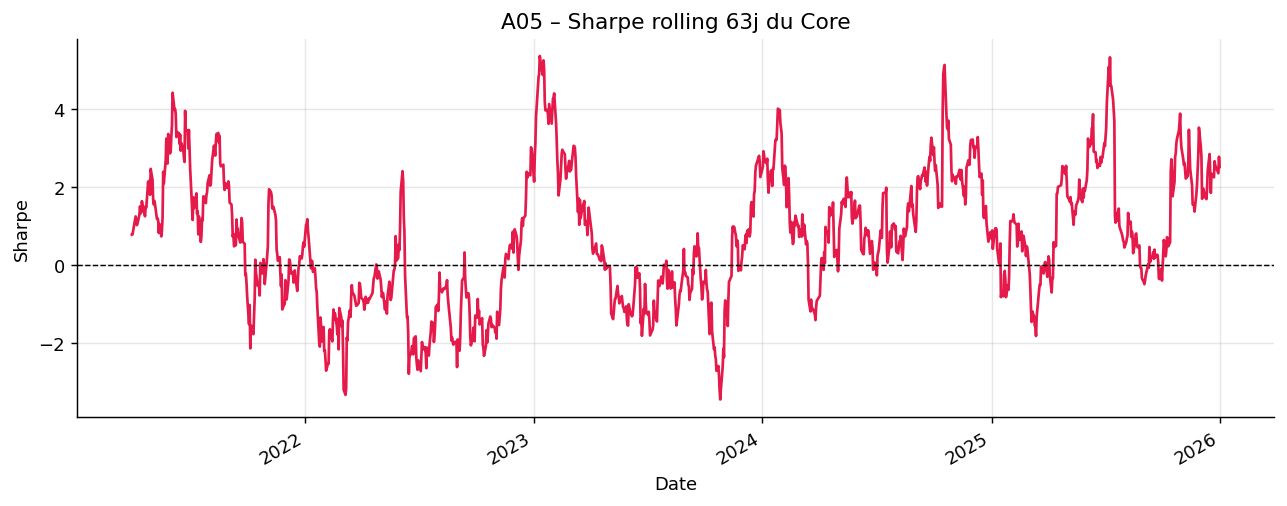

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A05_core_rolling_sharpe.png


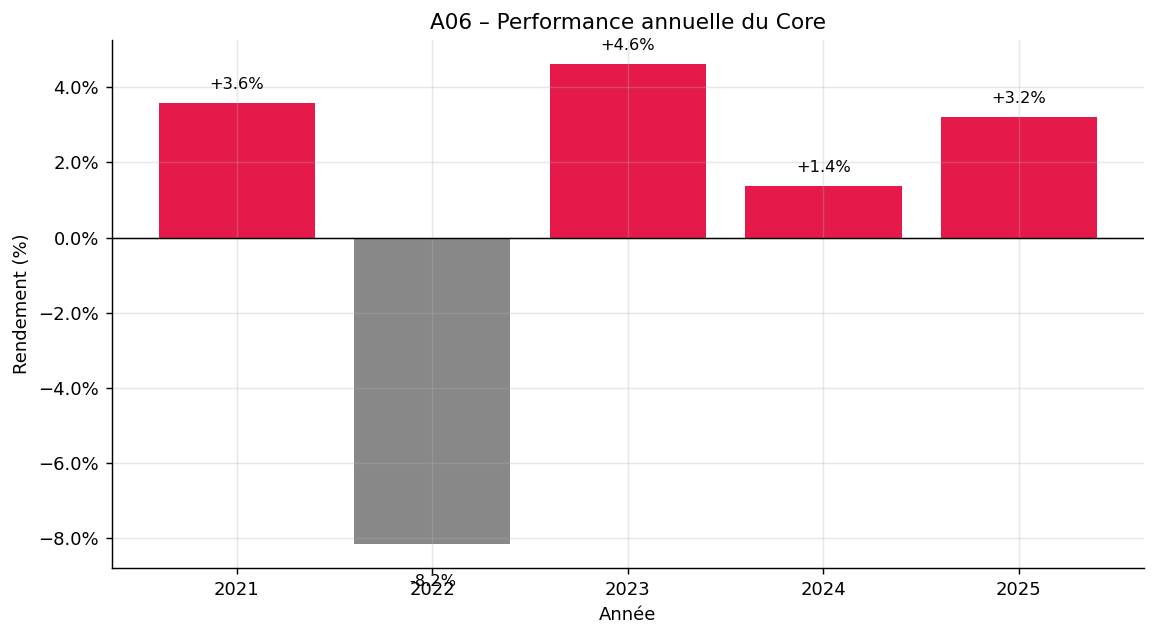

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A06_core_annual_bar.png


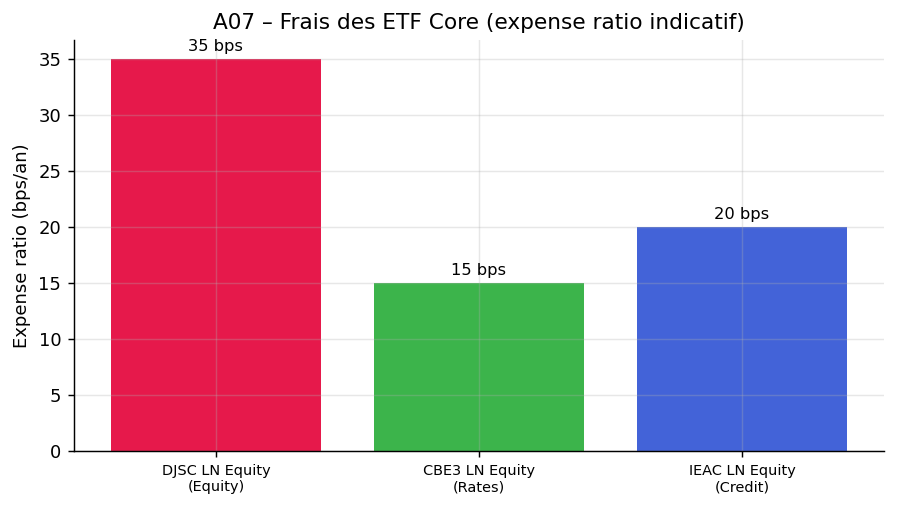

  -> /workspaces/Core_Satellite_Quant/outputs/figures/A07_core_fees_bar.png

[3] Section B – Poche Satellite (7 figures)...


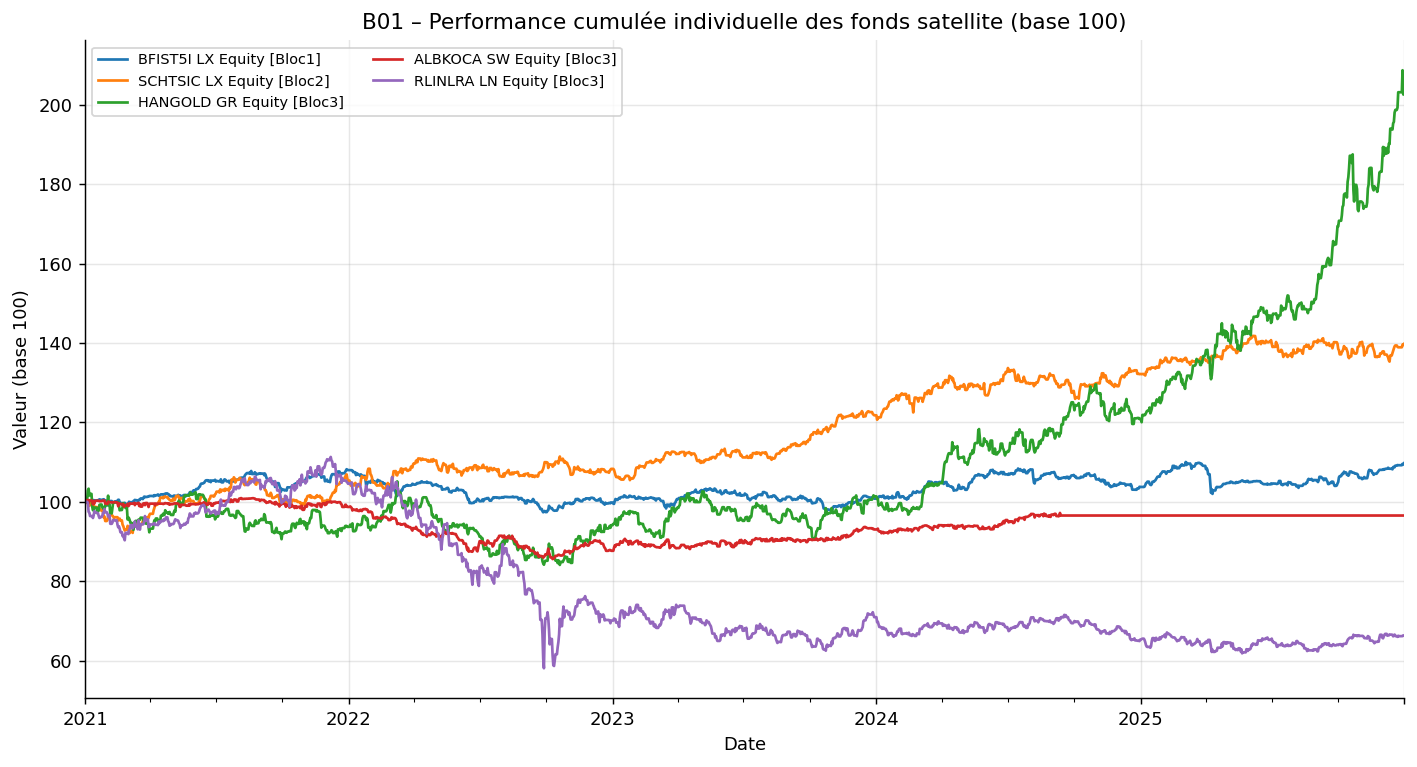

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B01_sat_fund_cum.png


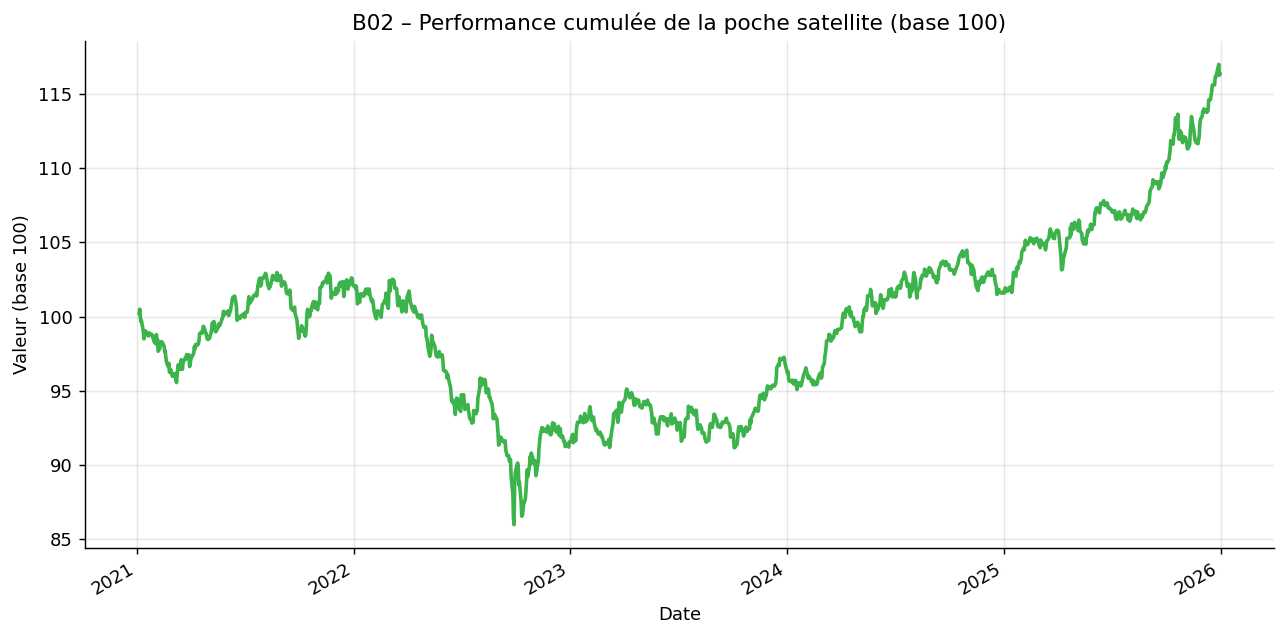

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B02_sat_pocket_cum.png


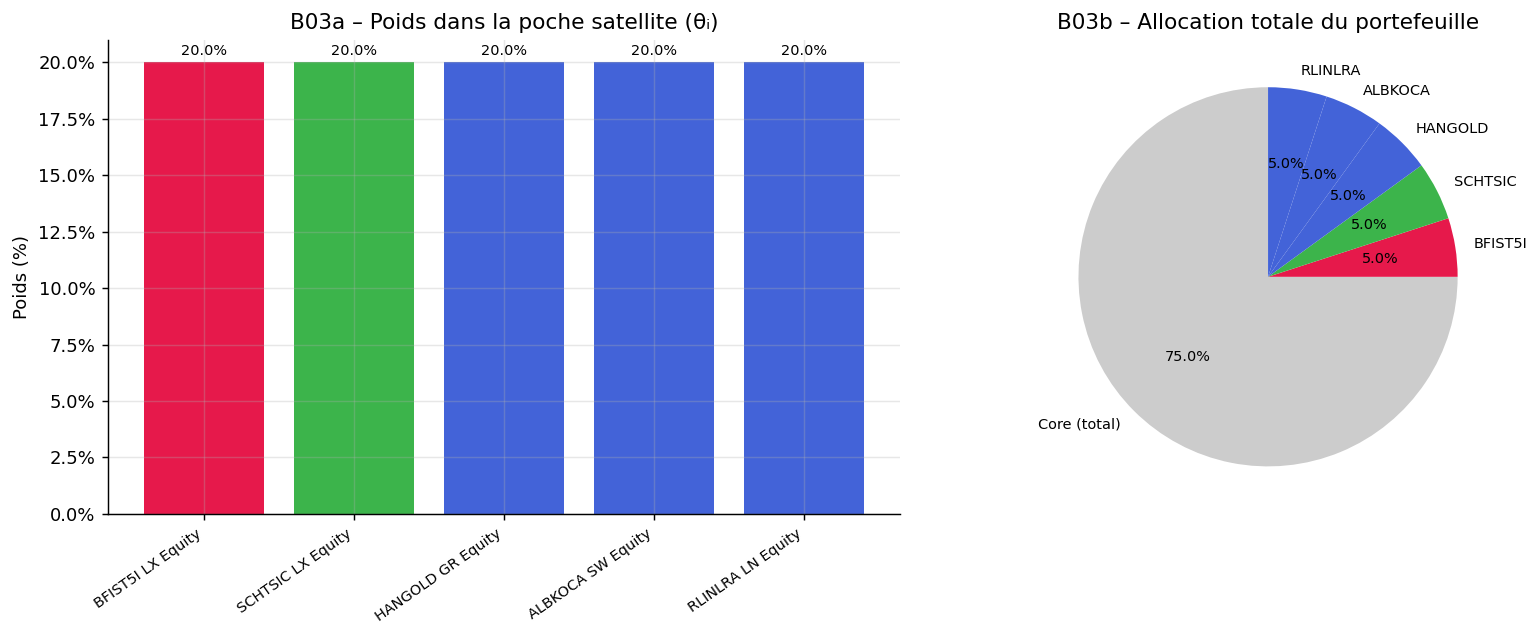

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B03_sat_weights.png


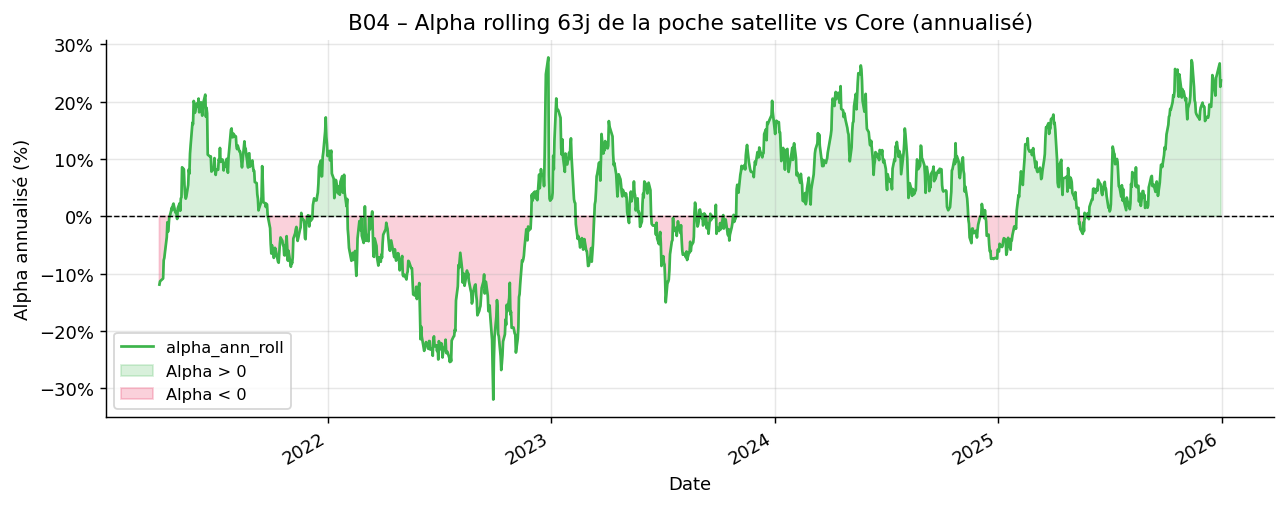

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B04_sat_rolling_alpha.png


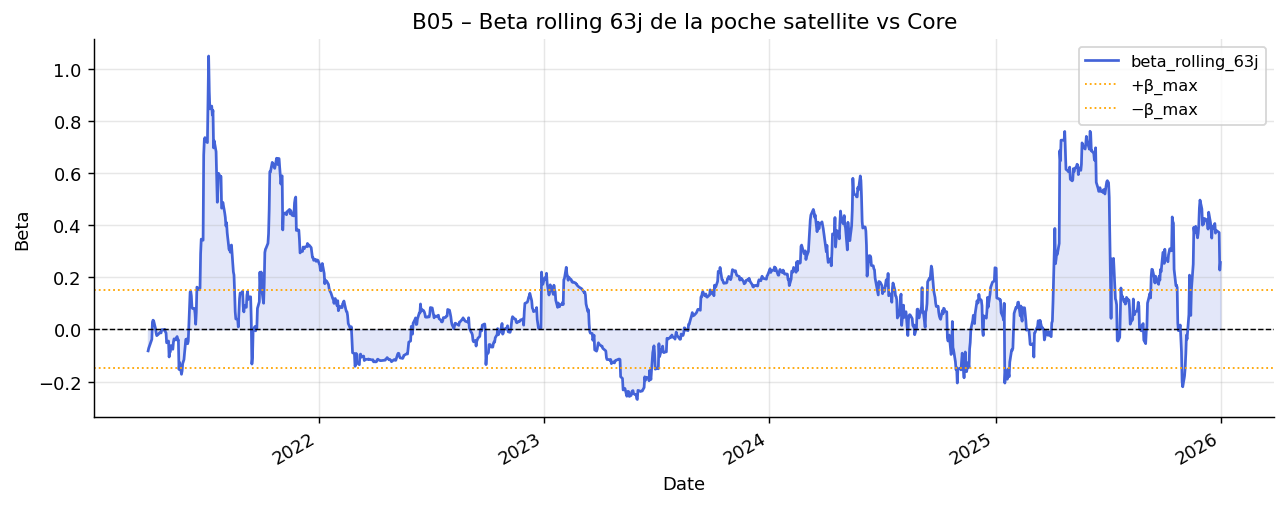

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B05_sat_rolling_beta.png


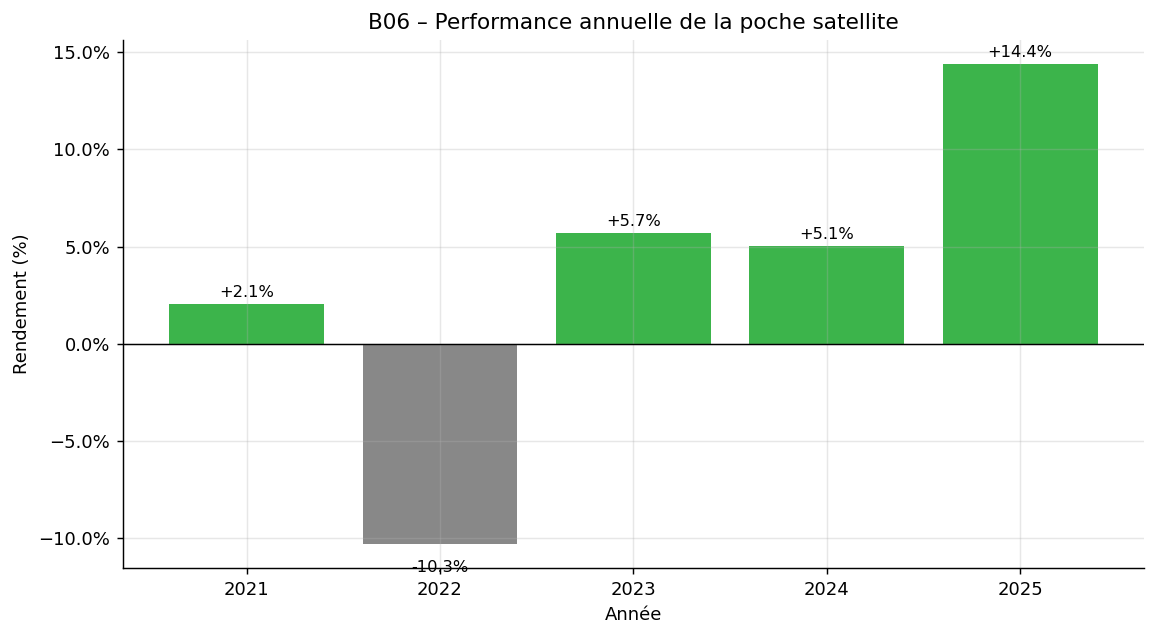

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B06_sat_annual.png


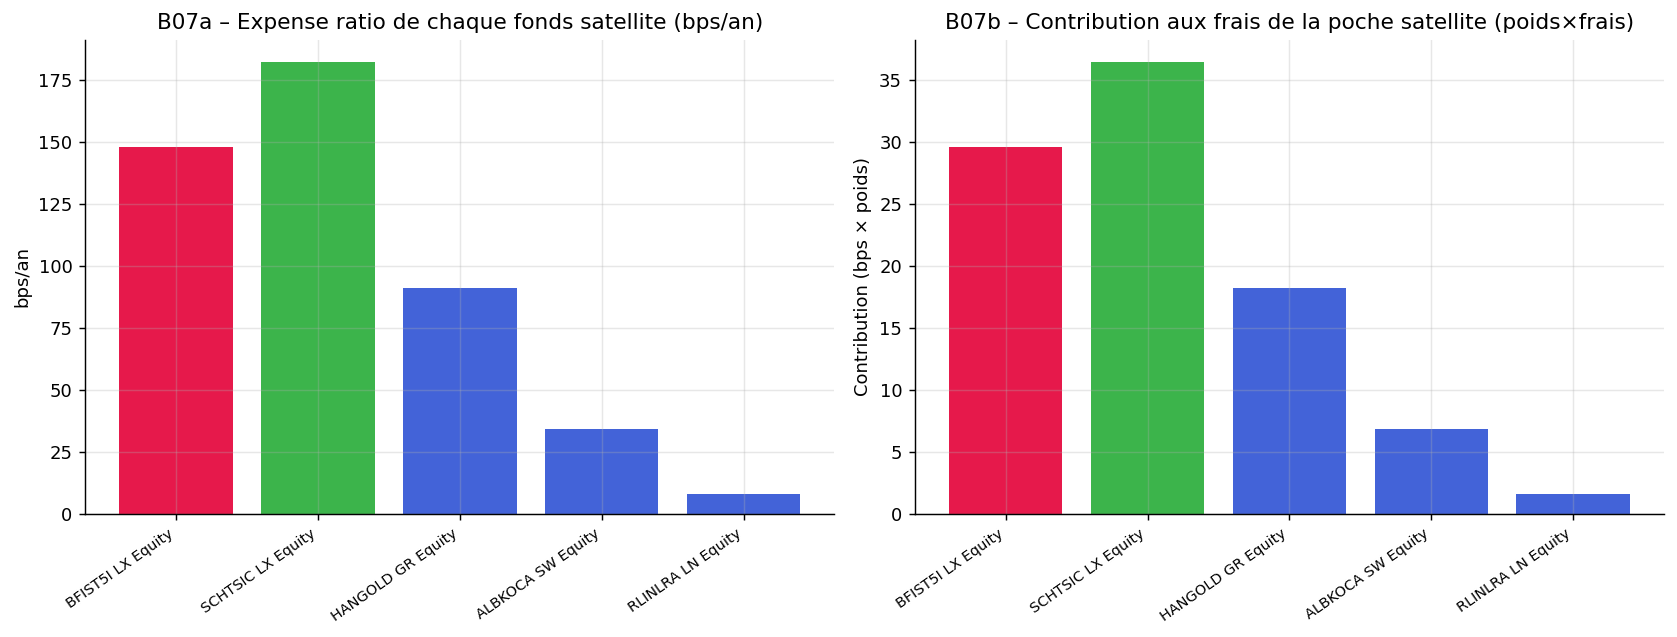

  -> /workspaces/Core_Satellite_Quant/outputs/figures/B07_sat_fees.png

[4] Section C – Core vs Satellite (4 figures)...


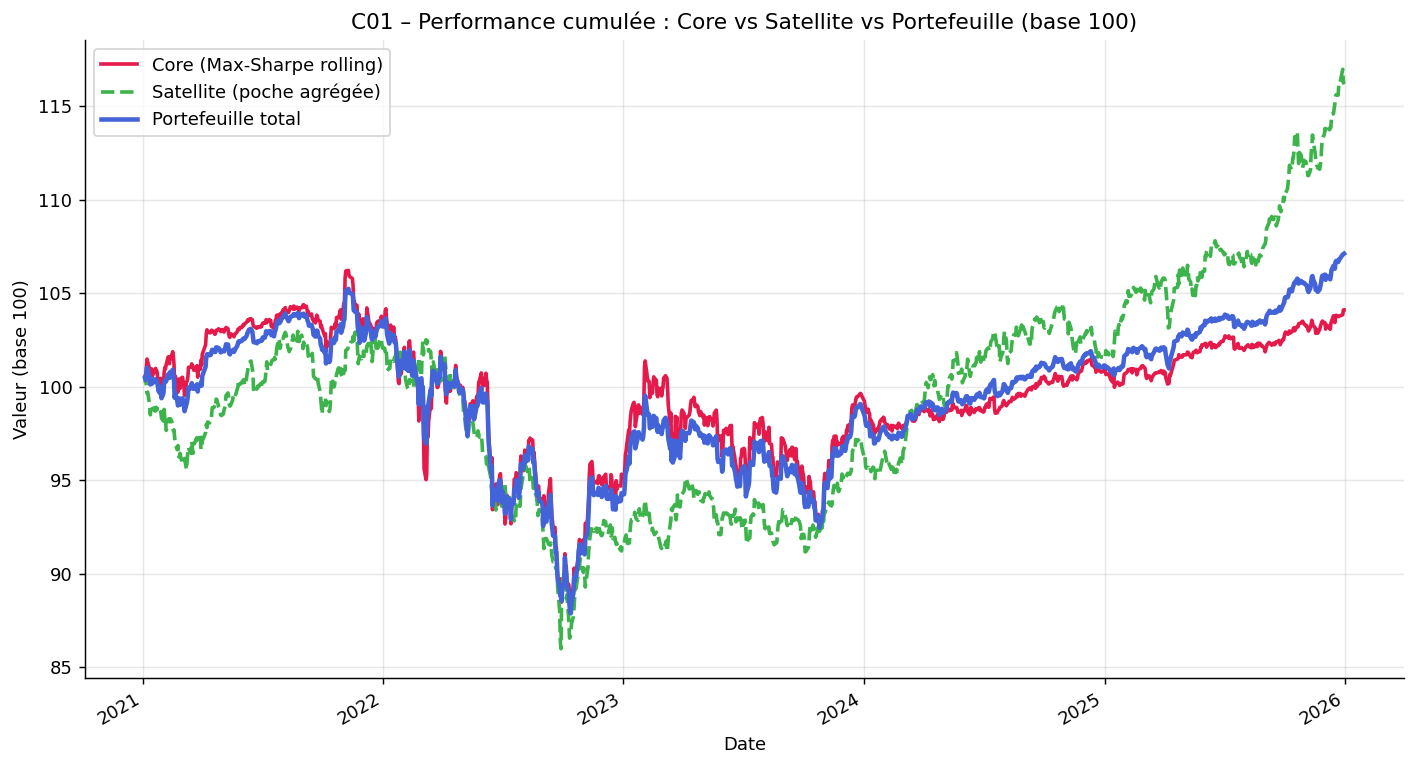

  -> /workspaces/Core_Satellite_Quant/outputs/figures/C01_core_vs_sat_cum.png


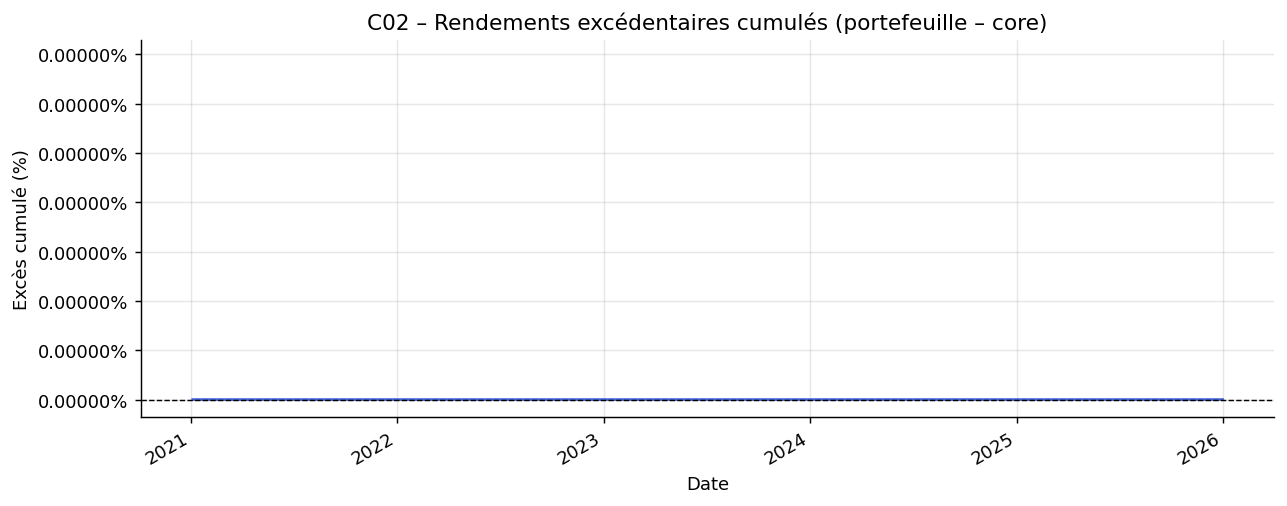

  -> /workspaces/Core_Satellite_Quant/outputs/figures/C02_excess_cum.png


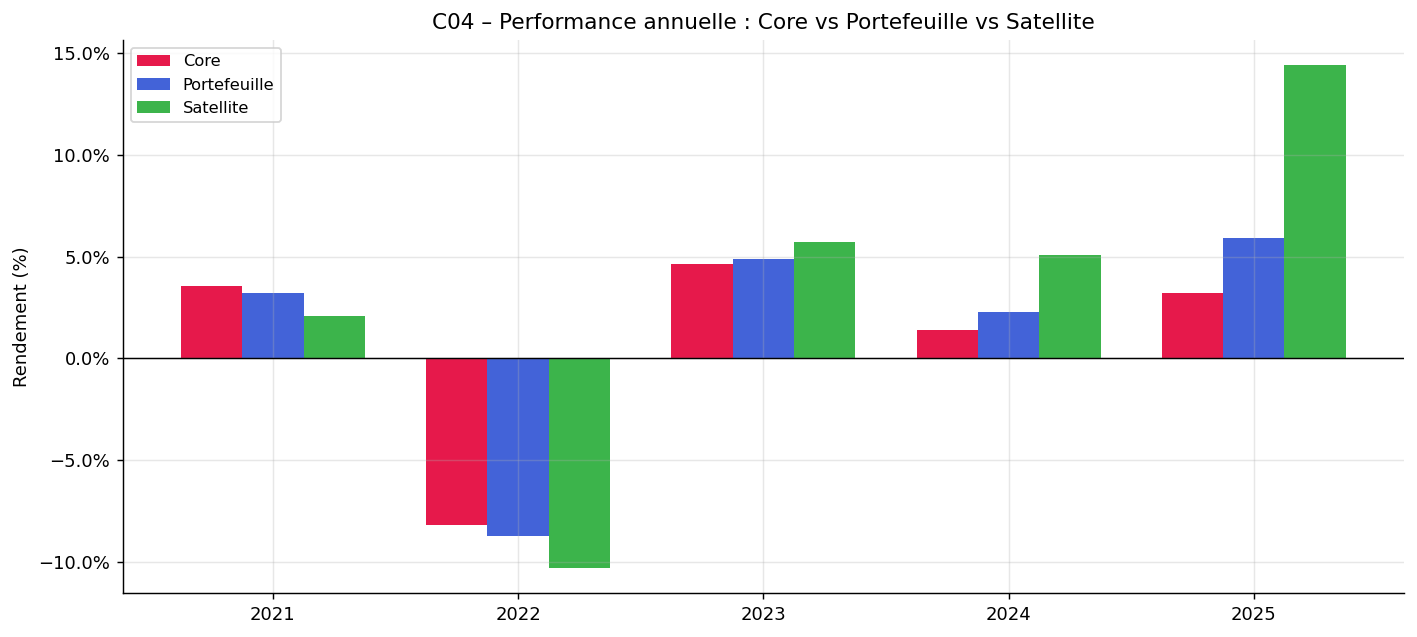

  -> /workspaces/Core_Satellite_Quant/outputs/figures/C04_annual_grouped_bar.png


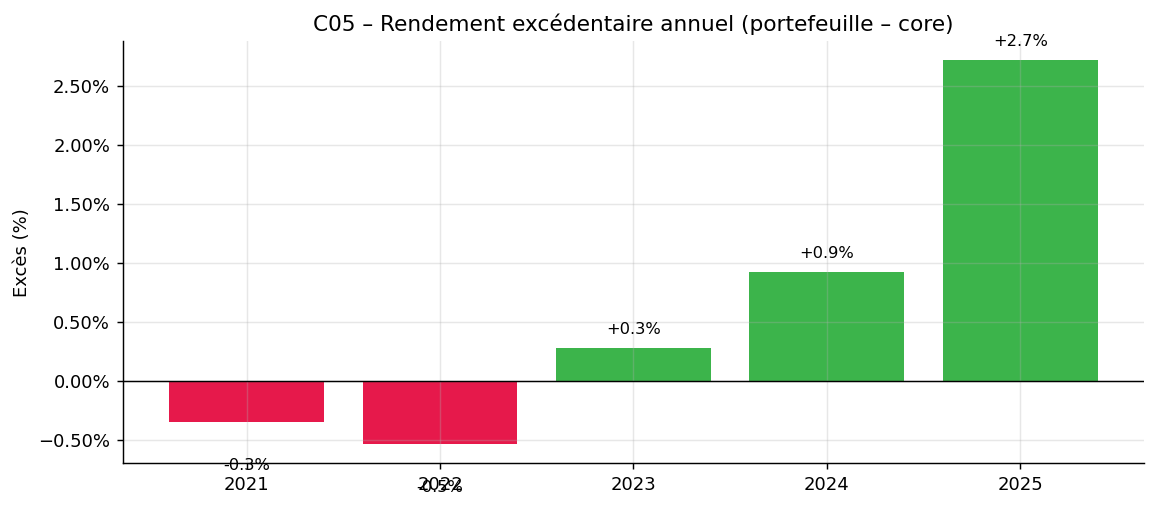

  -> /workspaces/Core_Satellite_Quant/outputs/figures/C05_excess_annual.png

[5] Section D – Portefeuille total (6 figures)...


/home/codespace/.local/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


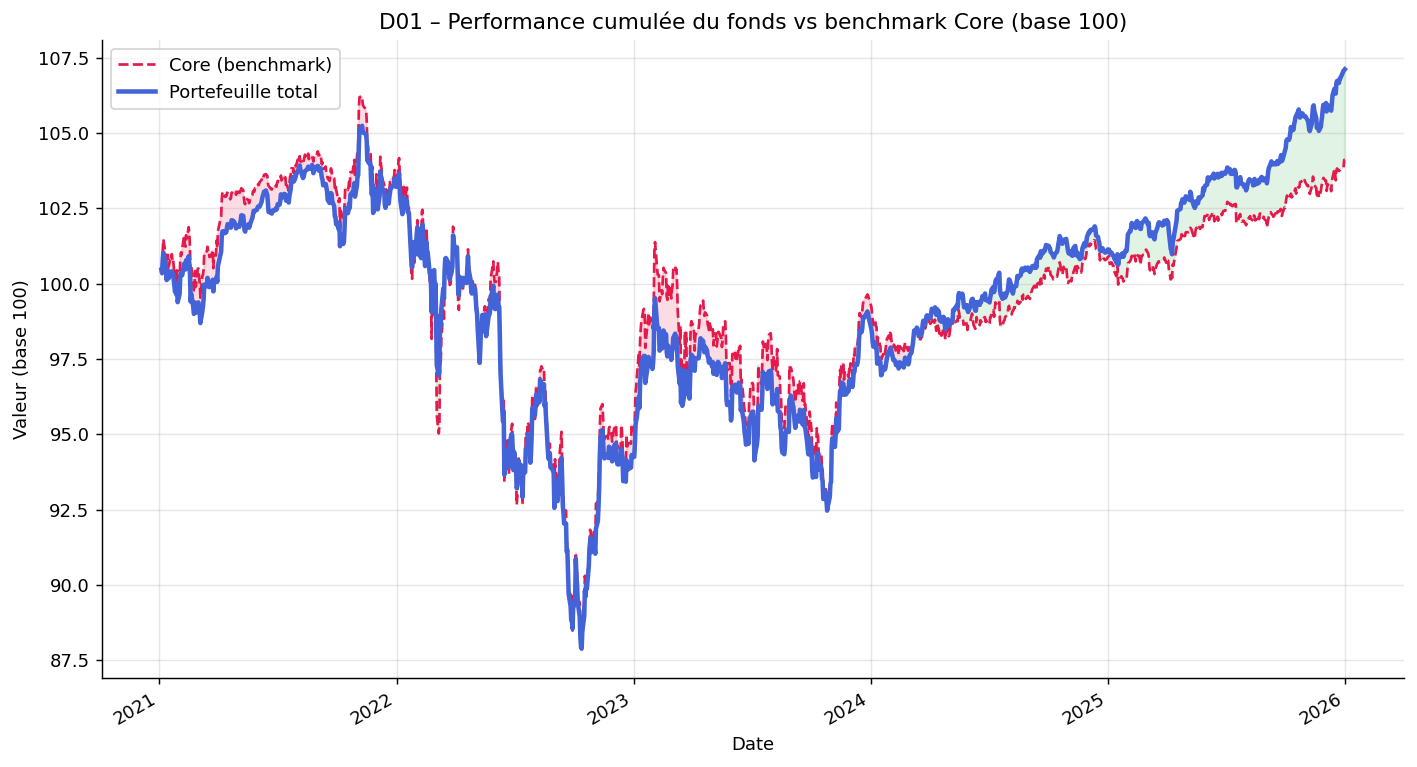

  -> /workspaces/Core_Satellite_Quant/outputs/figures/D01_portfolio_cum.png


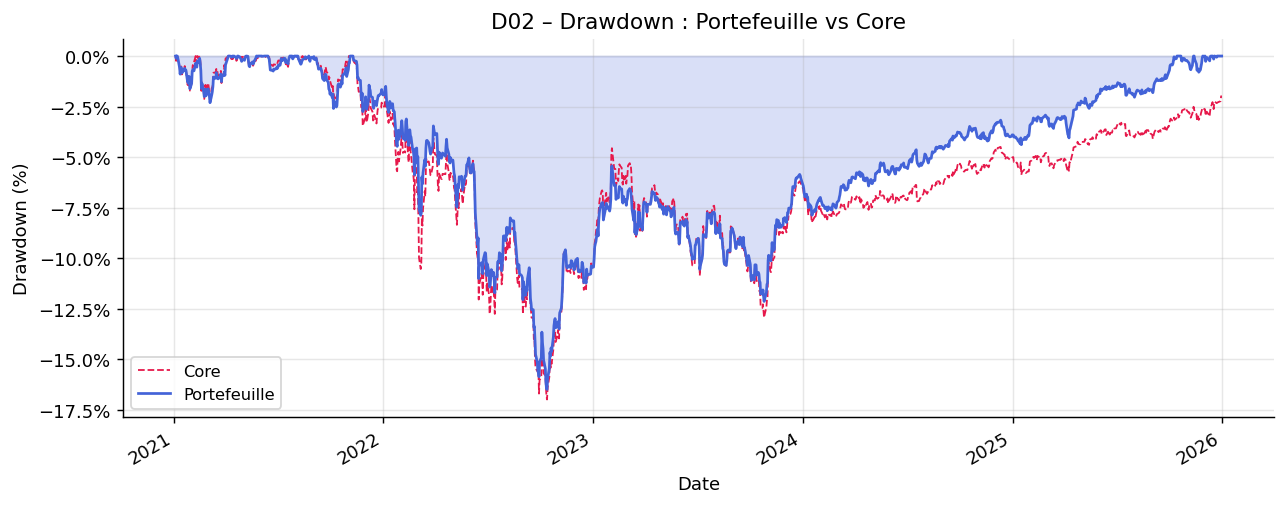

  -> /workspaces/Core_Satellite_Quant/outputs/figures/D02_portfolio_drawdown.png


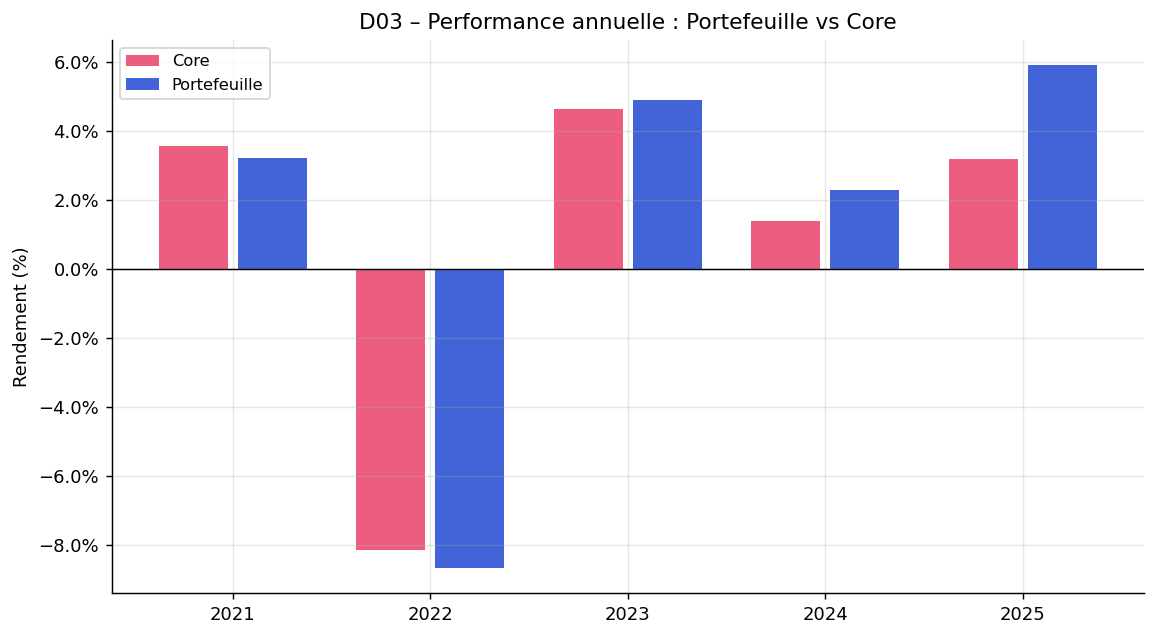

  -> /workspaces/Core_Satellite_Quant/outputs/figures/D03_portfolio_annual.png


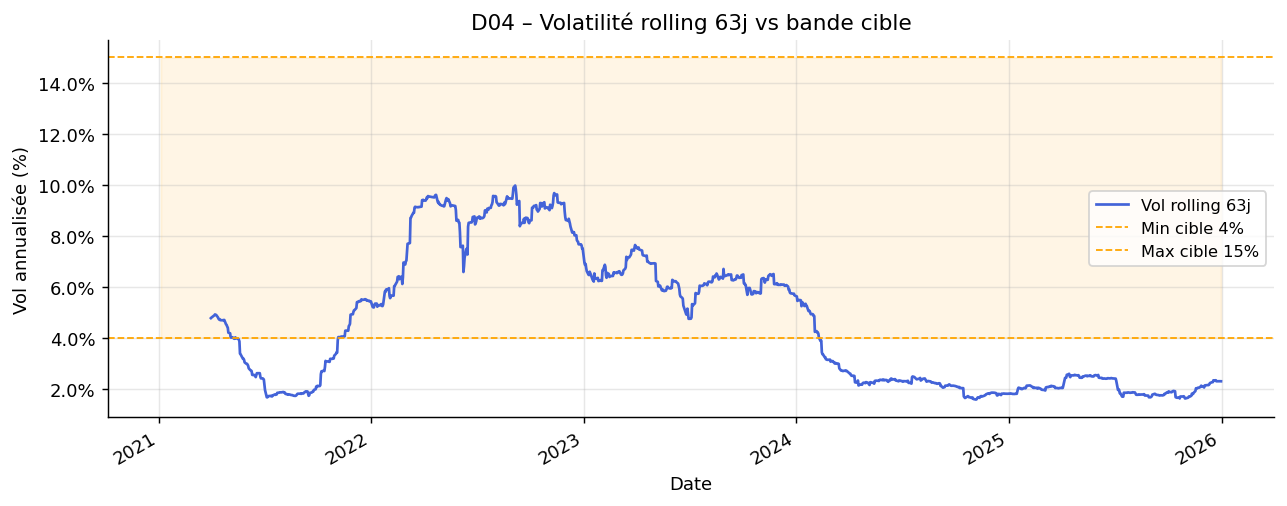

  -> /workspaces/Core_Satellite_Quant/outputs/figures/D04_portfolio_vol_target.png


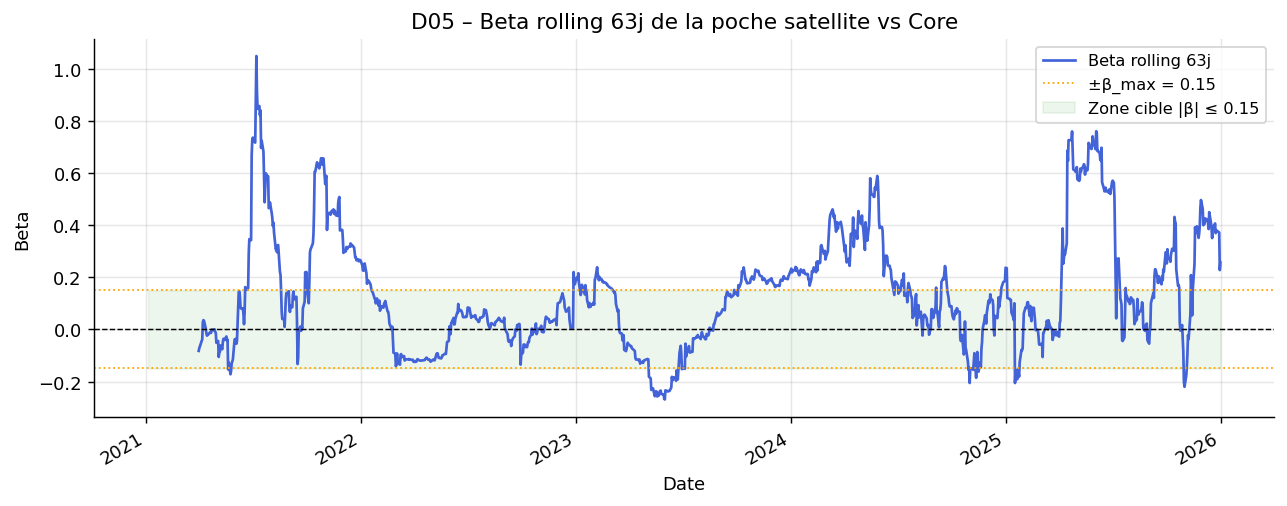

  -> /workspaces/Core_Satellite_Quant/outputs/figures/D05_beta_sat_rolling.png


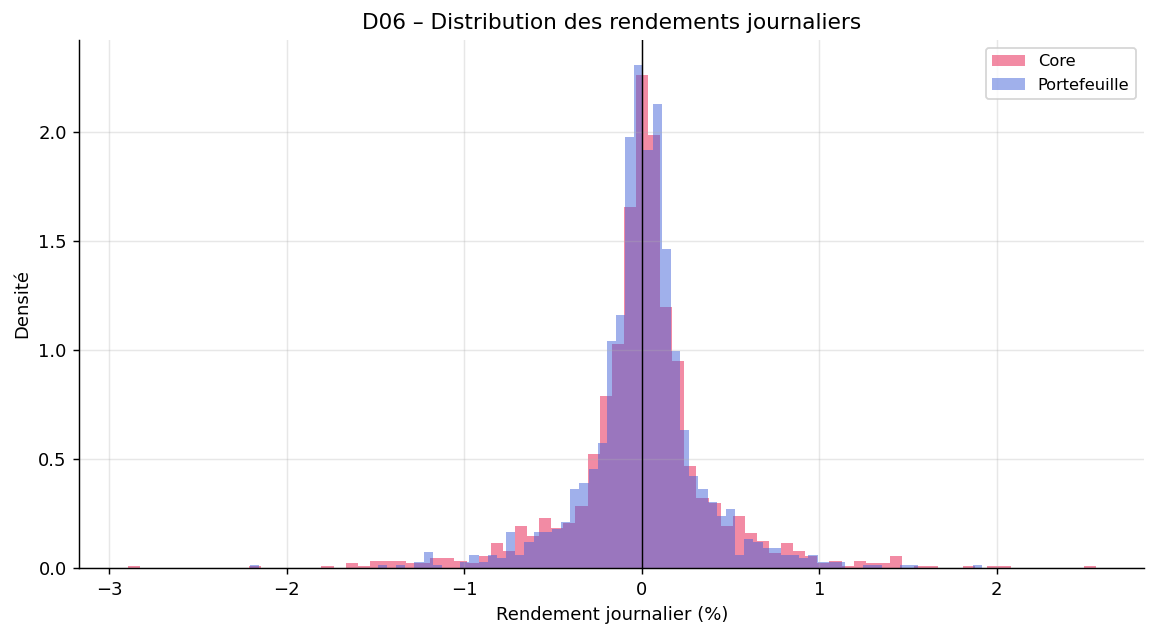

  -> /workspaces/Core_Satellite_Quant/outputs/figures/D06_portfolio_dist.png

  ✓  24 figures générées dans /workspaces/Core_Satellite_Quant/outputs/figures


In [26]:
from src.plots_report import main as plots_main
plots_main()

---
## Récapitulatif  Tableau de bord des métriques clés

Tableau synthétique IS vs OOS pour les 5 stratégies Core + le portefeuille total.

In [27]:

# ── Comparaison des 5 stratégies Core ──────────────────────────────────────
comp = pd.read_csv('outputs/core_portfolio_comparison.csv', index_col=0)
rename = {
    'IS_ret_ann':  'Rdt IS',   'IS_vol_ann':  'Vol IS',   'IS_sharpe':   'Sharpe IS',
    'OOS_ret_ann': 'Rdt OOS',  'OOS_vol_ann': 'Vol OOS',  'OOS_sharpe':  'Sharpe OOS',
    'OOS_mdd':     'MDD OOS',
}
comp = comp.rename(columns=rename)
pct_cols = [c for c in comp.columns if c not in ['Sharpe IS', 'Sharpe OOS', 'poids']]
fmt = {c: '{:.1%}' for c in pct_cols}
fmt.update({'Sharpe IS': '{:.2f}', 'Sharpe OOS': '{:.2f}'})

print('=== Comparaison des 5 stratégies Core (IS 2019-2020 / OOS 2021-2025) ===')
display(comp.drop(columns=['poids'], errors='ignore').style.format(fmt)
        .highlight_max(subset=['Rdt OOS', 'Sharpe OOS'], color='lightgreen')
        .highlight_min(subset=['MDD OOS', 'Vol OOS'],    color='lightblue'))

# ── Métriques complètes du portefeuille global Core-Satellite ───────────────
m = pd.read_csv('outputs/fond_metrics.csv', index_col=0)

# --- Bloc 1 : Rendement / Risque / Drawdown ---------------------------------
perf_data = {
    'Rendement ann.':       (m.loc['ret_ann_portfolio',    m.columns[0]], True),
    'Volatilité ann.':      (m.loc['vol_portfolio_ann',    m.columns[0]], True),
    'Sharpe':               (m.loc['sharpe_portfolio',     m.columns[0]], False),
    'Max Drawdown':         (m.loc['max_drawdown',         m.columns[0]], True),
}
perf_df = pd.DataFrame({
    'Portefeuille total': {k: f"{v:.2%}" if pct else f"{v:.3f}" for k, (v, pct) in perf_data.items()},
    'Poche Core': {
        'Rendement ann.': f"{m.loc['ret_ann_core', m.columns[0]]:.2%}",
        'Volatilité ann.': f"{m.loc['vol_core_ann', m.columns[0]]:.2%}",
        'Sharpe': f"{m.loc['sharpe_core', m.columns[0]]:.3f}",
        'Max Drawdown': '—',
    },
    'Poche Satellite': {
        'Rendement ann.': f"{m.loc['ret_ann_satellite', m.columns[0]]:.2%}",
        'Volatilité ann.': f"{m.loc['vol_satellite_ann', m.columns[0]]:.2%}",
        'Sharpe': '—',
        'Max Drawdown': '—',
    },
})

print('\n\n=== TABLEAU DE BORD – Portefeuille Core-Satellite (OOS 2021-2025) ===\n')
print('── Rendement / Risque ──')
display(perf_df)

# --- Bloc 2 : Alpha / Beta vs Core -----------------------------------------
ab_data = {
    'Alpha (ann.) vs Core': f"{m.loc['alpha_portfolio_ann', m.columns[0]]:.2%}",
    'Beta vs Core':         f"{m.loc['beta_portfolio',      m.columns[0]]:.3f}",
}
ab_df = pd.DataFrame(ab_data, index=['Portefeuille']).T
ab_df.columns.name = ''
print('\n── Alpha / Beta vs Core ──')
display(ab_df)

# --- Bloc 3 : Satellite Beta + Corrélation -----------------------------------
beta_data = {
    'Alpha sat. ann. vs Core': f"{m.loc['alpha_satellite_ann', m.columns[0]]:.2%}",
    'Beta sat. statique':      f"{m.loc['beta_satellite_static', m.columns[0]]:.3f}",
    'Beta sat. rolling moy.':  f"{m.loc['beta_sat_rolling_mean', m.columns[0]]:.3f}",
    'Beta sat. rolling std.':  f"{m.loc['beta_sat_rolling_std',  m.columns[0]]:.3f}",
    'ρ(Core, Satellite)':      f"{m.loc['corr_core_satellite',   m.columns[0]]:.3f}",
}
beta_df = pd.DataFrame(beta_data, index=['Satellite']).T
beta_df.columns.name = ''
print('\n── Décorrélation Satellite vs Core (bêta contrôlé ≤ 25%) ──')
display(beta_df)

# --- Bloc 4 : Allocation & Frais --------------------------------------------
alloc = {
    'w_core':  f"{m.loc['w_core', m.columns[0]]:.1%}",
    'w_sat':   f"{m.loc['w_sat',  m.columns[0]]:.1%}",
}
fees = {
    'Frais Core (contrib.)':     f"{m.loc['fees_core_contrib_bps', m.columns[0]]:.1f} bps",
    'Frais Sat. wavg.':          f"{m.loc['fees_sat_wavg_bps',     m.columns[0]]:.1f} bps",
    'Frais Sat. (contrib.)':     f"{m.loc['fees_sat_contrib_bps',  m.columns[0]]:.1f} bps",
    'Frais totaux portefeuille': f"{m.loc['fees_total_bps',        m.columns[0]]:.1f} bps",
    'Budget ≤ 80 bps':           '✓' if m.loc['fees_ok', m.columns[0]] else '✗',
}
af_df = pd.DataFrame({**alloc, **fees}, index=['Valeur']).T
af_df.columns.name = ''
print('\n── Allocation & Frais ──')
display(af_df)

# --- Bloc 5 : Performance annuelle ------------------------------------------
ann = pd.read_csv('outputs/fond_annual_perf.csv', index_col=0)
ann.index = ann.index.astype(int)
print('\n── Performance annuelle ──')
display(ann.style.format('{:.2%}')
        .map(lambda v: 'color: green' if v > 0 else 'color: red')
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='lightyellow'))


=== Comparaison des 5 stratégies Core (IS 2019-2020 / OOS 2021-2025) ===


,Rdt IS,Vol IS,Sharpe IS,Rdt OOS,Vol OOS,Sharpe OOS,MDD OOS
strategie,,,,,,,
Max Sharpe,7.2%,9.5%,0.75,0.4%,7.3%,0.05,-20.4%
Min Variance,1.5%,2.6%,0.59,0.1%,2.2%,0.07,-9.0%
Equal Weight,5.6%,7.6%,0.74,0.9%,5.9%,0.15,-16.4%
Risk Parity,0.9%,1.7%,0.54,0.5%,1.8%,0.28,-7.1%
Max Sharpe Rolling,8.1%,8.2%,0.99,0.9%,8.8%,0.10,-21.5%




=== TABLEAU DE BORD – Portefeuille Core-Satellite (OOS 2021-2025) ===

── Rendement / Risque ──


,Portefeuille total,Poche Core,Poche Satellite
Rendement ann.,1.36%,0.79%,3.02%
Volatilité ann.,5.22%,6.64%,5.54%
Sharpe,0.261,0.120,—
Max Drawdown,-16.49%,—,—



── Alpha / Beta vs Core ──


...

,Satellite
Alpha sat. ann. vs Core,3.14%
Beta sat. statique,0.033
Beta sat. rolling moy.,0.140
Beta sat. rolling std.,0.221
"ρ(Core, Satellite)",0.039



── Allocation & Frais ──


,Valeur
w_core,75.0%
w_sat,25.0%
Frais Core (contrib.),17.2 bps
Frais Sat. wavg.,92.6 bps
Frais Sat. (contrib.),23.1 bps
Frais totaux portefeuille,40.4 bps
Budget ≤ 80 bps,✓



── Performance annuelle ──


,portfolio,core,satellite
2021,3.22%,3.57%,2.07%
2022,-8.69%,-8.15%,-10.29%
2023,4.90%,4.62%,5.72%
2024,2.29%,1.37%,5.05%
2025,5.91%,3.20%,14.40%
